In [ ]:
!pip install nltk

In [ ]:
import nltk

In [ ]:
nltk.download("all")

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import gensim
from gensim.models import Word2Vec
import tensorflow as pd_tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN, GRU, LSTM, Bidirectional, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Set seeds for reproducibility
np.random.seed(42)
pd_tf.random.set_seed(42)


from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("Libraries imported successfully.")

Libraries imported successfully.


# Dataset Load

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define file paths
train_path = r"/content/drive/MyDrive/Question Answer Classification Dataset 4.csv"
test_path = r"/content/drive/MyDrive/Question Answer Classification Dataset_Test.csv"

# Load datasets
try:
    df_train = pd.read_csv(train_path, encoding='latin-1')  # Try latin-1 if utf-8 fails
    df_test = pd.read_csv(test_path, encoding='latin-1')
    print("Datasets loaded successfully.")
except Exception as e:
    print(f"Error loading data: {e}")

# Display first few rows
print("\nTraining Head:")
display(df_train.head())
print("\nTesting Head:")
display(df_test.head())

Datasets loaded successfully.

Training Head:


,QA Text,Class
0,<html> Question Title:\n <br> What are the nam...,Science & Mathematics
1,<html> Question Title:\n <br> can you tell me ...,Education & Reference
2,<html> Question Title:\n <br> Suggestions or A...,Politics & Government
3,<html> Question Title:\n <br> where can i find...,Entertainment & Music
4,<html> Question Title:\n <br> will the first t...,Sports



Testing Head:


,QA Text,Class
0,<html>\nQuestion Title:<br>Why does Zebras hav...,Science & Mathematics
1,<html>\nQuestion Title:<br>What did the itsy b...,Education & Reference
2,<html>\nQuestion Title:<br>What is the differe...,Education & Reference
3,<form>\nQuestion Title:<br>Why do women get PM...,Health
4,<html>\nQuestion Title:<br>If your co-worker i...,Health


# EDA

Missing values in Train:
QA Text    0
Class      0
dtype: int64


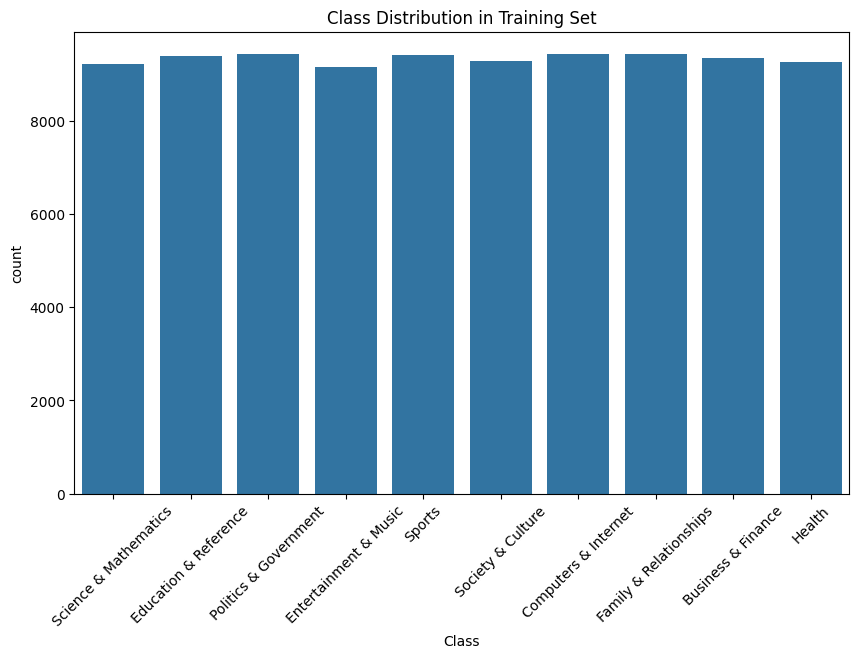

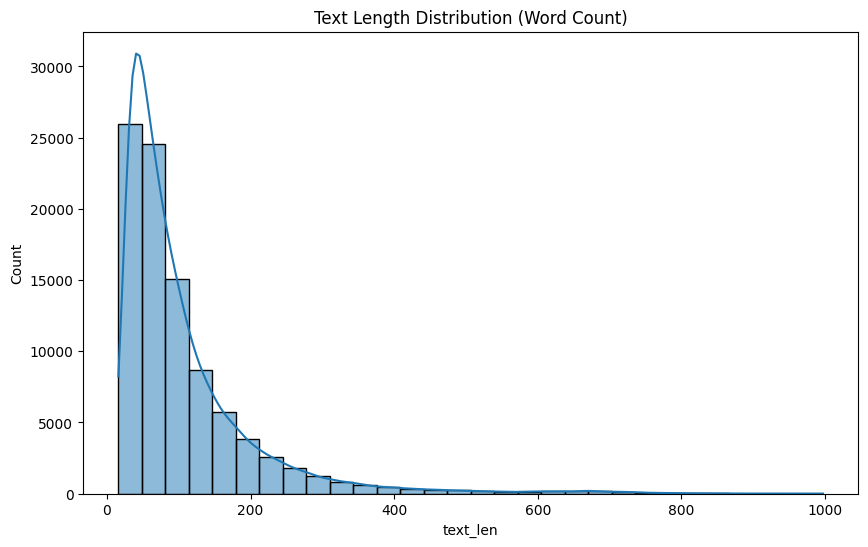

In [ ]:
# Check for missing values
print("Missing values in Train:")
print(df_train.isnull().sum())

# Drop missing values if any (simple strategy for now)
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

# Check class distribution
plt.figure(figsize=(10, 6))
sns.countplot(x=df_train.columns[-1], data=df_train) # Assuming label is the last column
plt.title('Class Distribution in Training Set')
plt.xticks(rotation=45)
plt.show()

# Text Length Distribution
text_col = df_train.columns[0] # Assuming text is first column
df_train['text_len'] = df_train[text_col].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 6))
sns.histplot(df_train['text_len'], bins=30, kde=True)
plt.title('Text Length Distribution (Word Count)')
plt.show()

# Pre-processing

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

# Initialize NLTK components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Ensure input is a string
    if not isinstance(text, str):
        return ""
    # Convert to lowercase
    text = text.lower()
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation and numbers, keeping only alphabetic characters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words and len(word) > 1]
    return " ".join(tokens)

print("Text preprocessing function defined.")

Text preprocessing function defined.


In [ ]:
text_col = df_train.columns[0]
label_col = 'Class' # Correctly identify the label column name

df_train['clean_text'] = df_train[text_col].apply(preprocess_text)
df_test['clean_text'] = df_test[text_col].apply(preprocess_text)

# Encode Labels
le = LabelEncoder()   #Business & Finance → 0  , Computers & Internet → 1
y_train = le.fit_transform(df_train[label_col])
y_test = le.transform(df_test[label_col])

num_classes = len(le.classes_)
print(f"Classes: {le.classes_}")
print("Text preprocessing and label encoding complete for both datasets.")

Classes: ['Business & Finance' 'Computers & Internet' 'Education & Reference'
 'Entertainment & Music' 'Family & Relationships' 'Health'
 'Politics & Government' 'Science & Mathematics' 'Society & Culture'
 'Sports']
Text preprocessing and label encoding complete for both datasets.


# Word Cloud

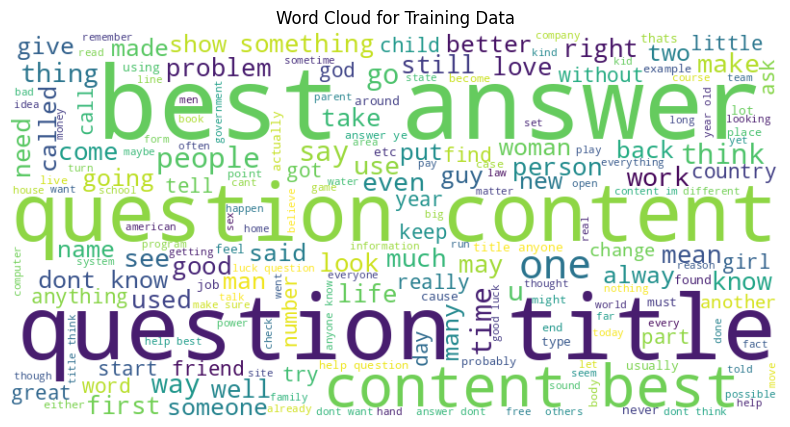

Word cloud generated and displayed for training data.


In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Ensure 'clean_text' column exists for df_train
# This step might be redundant if the preprocessing cell was run, but ensures this cell runs independently.
if 'clean_text' not in df_train.columns:
    text_col = df_train.columns[0]
    # Assuming preprocess_text function is defined and necessary NLTK data is downloaded
    df_train['clean_text'] = df_train[text_col].apply(preprocess_text)

# Concatenate all clean text from the training dataset
all_train_text = " ".join(df_train['clean_text'].dropna().astype(str))

# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_train_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud for Training Data')
plt.show()

print("Word cloud generated and displayed for training data.")

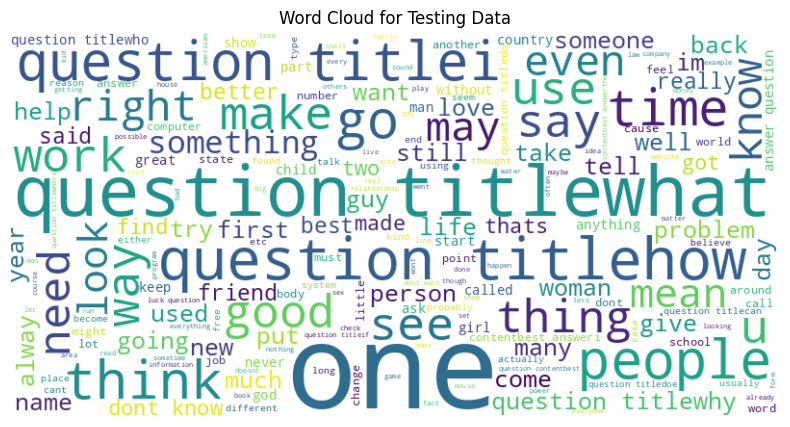

Word cloud generated and displayed for testing data.


In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Concatenate all clean text from the testing dataset
all_test_text = " ".join(df_test['clean_text'].dropna().astype(str))

# Create a WordCloud object
wordcloud_test = WordCloud(width=800, height=400, background_color='white').generate(all_test_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_test, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud for Testing Data')
plt.show()

print("Word cloud generated and displayed for testing data.")

# TF-IDF

In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features for efficiency
X_train_tfidf = tfidf_vectorizer.fit_transform(df_train['clean_text'])
X_test_tfidf = tfidf_vectorizer.transform(df_test['clean_text'])

print("TF-IDF vectorization complete for training and testing data.")
print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

TF-IDF vectorization complete for training and testing data.
Shape of X_train_tfidf: (93333, 5000)
Shape of X_test_tfidf: (59999, 5000)


# Applying ml model (LogisticRegression)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6519608660144336

Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.48      0.49      6000
           1       0.79      0.81      0.80      6000
           2       0.48      0.46      0.47      6000
           3       0.64      0.60      0.62      6000
           4       0.68      0.70      0.69      5999
           5       0.71      0.74      0.73      6000
           6       0.71      0.71      0.71      6000
           7       0.63      0.72      0.67      6000
           8       0.54      0.53      0.53      6000
           9       0.82      0.77      0.80      6000

    accuracy                           0.65     59999
   macro avg       0.65      0.65      0.65     59999
weighted avg       0.65      0.65      0.65     59999


Confusion Matrix:
[[2891  366  537  318  323  277  371  357  441  119]
 [ 325 4879  183  195   63   42   47  144   62   60]
 [ 498  213 2747  230  137  229  409  911  483  143]
 [ 320  2

#Pre-processing (stemming) & using another ml model (LogisticRegression)

In [ ]:
from nltk.stem import PorterStemmer

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def preprocess_text_stem(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize
    tokens = nltk.word_tokenize(text)
    # Remove stopwords and stem
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words and len(word) > 1]
    return " ".join(tokens)

print("Text preprocessing (STEMMING) function defined.")


Text preprocessing (STEMMING) function defined.


In [ ]:
df_train["stem_text"] = df_train[text_col].apply(preprocess_text_stem)
df_test["stem_text"]  = df_test[text_col].apply(preprocess_text_stem)


In [ ]:
label_col = "Class"   # your label column name

le = LabelEncoder()

y_train = le.fit_transform(df_train[label_col])
y_test  = le.transform(df_test[label_col])

print("Labels encoded successfully.")
print("Classes:", le.classes_)

Labels encoded successfully.
Classes: ['Business & Finance' 'Computers & Internet' 'Education & Reference'
 'Entertainment & Music' 'Family & Relationships' 'Health'
 'Politics & Government' 'Science & Mathematics' 'Society & Culture'
 'Sports']


In [ ]:
X_train_text, X_val_text, y_train_split, y_val_split = train_test_split(
    df_train['clean_text'],
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

hyperparameter tuning (TF-IDF + Logistic Regression))

In [ ]:
C_values = [0.1, 0.5, 1.0, 2.0]
max_features_list = [3000, 5000, 10000]

best_f1 = 0
best_params = None
best_vectorizer = None
best_model = None

for max_feat in max_features_list:
    tfidf = TfidfVectorizer(max_features=max_feat)

    X_train_vec = tfidf.fit_transform(X_train_text)
    X_val_vec = tfidf.transform(X_val_text)

    for C in C_values:
        model = LogisticRegression(
            C=C,
            max_iter=1000,
            n_jobs=-1
        )
        model.fit(X_train_vec, y_train_split)

        val_pred = model.predict(X_val_vec)
        val_f1 = f1_score(y_val_split, val_pred, average="macro")

        print(f"max_features={max_feat}, C={C} → Val F1 = {val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_params = (max_feat, C)
            best_vectorizer = tfidf
            best_model = model

print("\n✅ BEST PARAMETERS")
print("max_features, C =", best_params)
print("Best Validation F1:", round(best_f1, 4))

max_features=3000, C=0.1 → Val F1 = 0.6412
max_features=3000, C=0.5 → Val F1 = 0.6504
max_features=3000, C=1.0 → Val F1 = 0.6483
max_features=3000, C=2.0 → Val F1 = 0.6461
max_features=5000, C=0.1 → Val F1 = 0.6502
max_features=5000, C=0.5 → Val F1 = 0.6624
max_features=5000, C=1.0 → Val F1 = 0.6637
max_features=5000, C=2.0 → Val F1 = 0.6587
max_features=10000, C=0.1 → Val F1 = 0.6543
max_features=10000, C=0.5 → Val F1 = 0.6732
max_features=10000, C=1.0 → Val F1 = 0.6761
max_features=10000, C=2.0 → Val F1 = 0.6707

✅ BEST PARAMETERS
max_features, C = (10000, 1.0)
Best Validation F1: 0.6761


In [ ]:
#Train final model on FULL training data

# Refit TF-IDF on full training data
best_max_feat, best_C = best_params

final_tfidf = TfidfVectorizer(max_features=best_max_feat)
X_train_final = final_tfidf.fit_transform(df_train["stem_text"])
X_test_final = final_tfidf.transform(df_test["stem_text"])

final_model = LogisticRegression(
    C=best_C,
    max_iter=1000,
    n_jobs=-1
)
final_model.fit(X_train_final, y_train)


LogisticRegression(max_iter=1000, n_jobs=-1)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_test_pred = final_model.predict(X_test_final)

print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Test Accuracy: 0.6673111218520309

Classification Report:

                        precision    recall  f1-score   support

    Business & Finance       0.54      0.47      0.51      6000
  Computers & Internet       0.81      0.82      0.82      6000
 Education & Reference       0.50      0.47      0.48      6000
 Entertainment & Music       0.66      0.63      0.64      6000
Family & Relationships       0.70      0.69      0.70      5999
                Health       0.72      0.76      0.74      6000
 Politics & Government       0.72      0.73      0.72      6000
 Science & Mathematics       0.63      0.74      0.68      6000
     Society & Culture       0.55      0.53      0.54      6000
                Sports       0.82      0.82      0.82      6000

              accuracy                           0.67     59999
             macro avg       0.66      0.67      0.66     59999
          weighted avg       0.66      0.67      0.66     59999


Confusion Matrix:
[[2838  347  533  326  

***comparison***

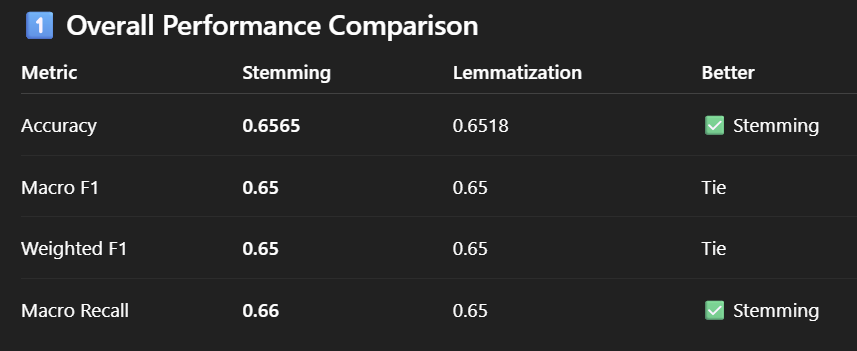


Using Logistic Regression with TF-IDF features, the stemming-based model achieved a higher accuracy of 65.65% compared to 65.18% for lemmatization. Both approaches produced similar macro F1-scores (0.65), but stemming showed slightly better macro recall (0.66 vs 0.65). Class-wise analysis and confusion matrices indicate that stemming reduced misclassification among closely related categories such as Science & Mathematics and Society & Culture. Overall, stemming provided marginally better and more consistent performance on this dataset.


# Deep Neural Network on TF-IDF

In [ ]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.1 MB/s eta 0:00:00


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, accuracy_score

# Ensure NLTK resources
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

# 1. Clean Text Function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text) # Remove HTML
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove special chars
    return text

# Apply cleaning
print("Cleaning text...")
df_train['Clean_Text'] = df_train['QA Text'].apply(clean_text)
df_test['Clean_Text'] = df_test['QA Text'].apply(clean_text)

# 2. Stemming & Lemmatization
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_text(text):
    tokens = word_tokenize(text)
    return ' '.join([stemmer.stem(word) for word in tokens])

def lemma_text(text):
    tokens = word_tokenize(text)
    return ' '.join([lemmatizer.lemmatize(word) for word in tokens])

print("Applying Stemming and Lemmatization...")
df_train['Stemmed_Text'] = df_train['Clean_Text'].apply(stem_text)
df_test['Stemmed_Text'] = df_test['Clean_Text'].apply(stem_text)

df_train['Lemma_Text'] = df_train['Clean_Text'].apply(lemma_text)
df_test['Lemma_Text'] = df_test['Clean_Text'].apply(lemma_text)

# Label Encoding
le = LabelEncoder()
y_train = le.fit_transform(df_train['Class'])
y_test = le.transform(df_test['Class'])
num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)
print("Preprocessing Done.")

Cleaning text...
Applying Stemming and Lemmatization...
Preprocessing Done.


In [ ]:
# TF-IDF Vectorization (Max Features 5000)
print("Extracting TF-IDF Features...")

# STEMMING
vectorizer_stem = TfidfVectorizer(max_features=5000)
X_train_stem = vectorizer_stem.fit_transform(df_train['Stemmed_Text']).toarray()
X_test_stem = vectorizer_stem.transform(df_test['Stemmed_Text']).toarray()

# LEMMATIZATION
vectorizer_lemma = TfidfVectorizer(max_features=5000)
X_train_lemma = vectorizer_lemma.fit_transform(df_train['Lemma_Text']).toarray()
X_test_lemma = vectorizer_lemma.transform(df_test['Lemma_Text']).toarray()

print("Shapes:", X_train_stem.shape, X_train_lemma.shape)

Extracting TF-IDF Features...
Shapes: (93333, 5000) (93333, 5000)


In [ ]:
def build_model(hp):
    model = Sequential()

    # Tunable First Layer
    model.add(Dense(units=hp.Int('units_1', min_value=32, max_value=512, step=32),
                    activation='relu', input_shape=(5000,)))
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Tunable Second Layer
    model.add(Dense(units=hp.Int('units_2', min_value=32, max_value=256, step=32),
                    activation='relu'))
    model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# --- 1. STEMMING PIPELINE ---
print("\n=== Tuning DNN with Stemming ===")
tuner_stem = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuning_dir',
    project_name='stemming_tuning'
)

tuner_stem.search(X_train_stem, y_train_cat, epochs=50, validation_split=0.2, callbacks=[early_stop])
best_hps_stem = tuner_stem.get_best_hyperparameters(num_trials=1)[0]

print("\nTraining Best Stemming Model...")
model_stem = tuner_stem.hypermodel.build(best_hps_stem)
checkpoint_stem = ModelCheckpoint('best_model_stemming.keras', monitor='val_accuracy', save_best_only=True, mode='max')
history_stem = model_stem.fit(X_train_stem, y_train_cat,
                              epochs=50,
                              validation_split=0.2,
                              callbacks=[early_stop, checkpoint_stem])

# --- 2. LEMMATIZATION PIPELINE ---
print("\n=== Tuning DNN with Lemmatization ===")
tuner_lemma = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuning_dir',
    project_name='lemmatization_tuning'
)

tuner_lemma.search(X_train_lemma, y_train_cat, epochs=50, validation_split=0.2, callbacks=[early_stop])
best_hps_lemma = tuner_lemma.get_best_hyperparameters(num_trials=1)[0]

print("\nTraining Best Lemmatization Model...")
model_lemma = tuner_lemma.hypermodel.build(best_hps_lemma)
checkpoint_lemma = ModelCheckpoint('best_model_lemmatization.keras', monitor='val_accuracy', save_best_only=True, mode='max')
history_lemma = model_lemma.fit(X_train_lemma, y_train_cat,
                                epochs=50,
                                validation_split=0.2,
                                callbacks=[early_stop, checkpoint_lemma])

Trial 5 Complete [00h 00m 50s]
val_accuracy: 0.6652381420135498

Best val_accuracy So Far: 0.6737022399902344
Total elapsed time: 00h 04m 49s

Training Best Lemmatization Model...
Epoch 1/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.2533 - loss: 2.1368 - val_accuracy: 0.6298 - val_loss: 1.4038
Epoch 2/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.5772 - loss: 1.4123 - val_accuracy: 0.6633 - val_loss: 1.1382
Epoch 3/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6373 - loss: 1.1979 - val_accuracy: 0.6693 - val_loss: 1.0693
Epoch 4/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6633 - loss: 1.1109 - val_accuracy: 0.6733 - val_loss: 1.0430
Epoch 5/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6774 - loss: 1.0624 - val_accuracy: 0.6739 - val_loss: 1.0317
Epoch 6/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6870 - loss: 1.0252 - val_accuracy: 0.6739 - val_loss: 1.0273
Epoch 7/50
2334/2334 ━━━━━━━━━━━━━━━━━━


--- Evaluation ---
Stemming Model Accuracy: 0.6682
Lemmatization Model Accuracy: 0.6646
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

Classification Report (Stemming):
                        precision    recall  f1-score   support

    Business & Finance       0.57      0.46      0.51      6000
  Computers & Internet       0.80      0.83      0.82      6000
 Education & Reference       0.49      0.48      0.49      6000
 Entertainment & Music       0.63      0.63      0.63      6000
Family & Relationships       0.67      0.74      0.70      5999
                Health       0.72      0.76      0.74      6000
 Politics & Government       0.70      0.75      0.72      6000
 Science & Mathematics       0.68      0.70      0.69      6000
     Society & Culture       0.56      0.53      0.55      6000
                Sports       0.83      0.80      0.82      6000

              accuracy                           0.67     59999
             macro a

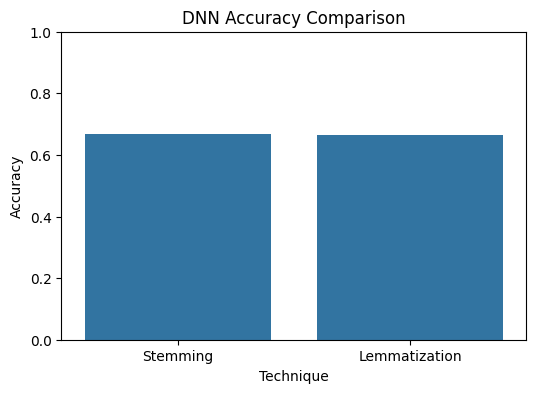

In [ ]:
# Evaluate on Test Set
print("\n--- Evaluation ---")
loss_stem, acc_stem = model_stem.evaluate(X_test_stem, y_test_cat, verbose=0)
loss_lemma, acc_lemma = model_lemma.evaluate(X_test_lemma, y_test_cat, verbose=0)

print(f"Stemming Model Accuracy: {acc_stem:.4f}")
print(f"Lemmatization Model Accuracy: {acc_lemma:.4f}")

y_pred_stem = np.argmax(model_stem.predict(X_test_stem), axis=1)
y_pred_lemma = np.argmax(model_lemma.predict(X_test_lemma), axis=1)

print("\nClassification Report (Stemming):")
print(classification_report(y_test, y_pred_stem, target_names=le.classes_))

print("\nClassification Report (Lemmatization):")
print(classification_report(y_test, y_pred_lemma, target_names=le.classes_))

# Visual Comparison
results_df = pd.DataFrame({
    'Technique': ['Stemming', 'Lemmatization'],
    'Accuracy': [acc_stem, acc_lemma]
})
plt.figure(figsize=(6, 4))
sns.barplot(x='Technique', y='Accuracy', data=results_df)
plt.title('DNN Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

# Tokenization

In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize

# Ensure NLTK resources are available (punkt for word_tokenize)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True) # Download punkt_tab

# 1. Clean Text Function (re-defining for robustness, in case it was lost)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text) # Remove HTML
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove special chars
    return text

# Apply cleaning to create 'Clean_Text' column
print("Re-cleaning 'QA Text' column to create 'Clean_Text' for df_train...")
df_train['Clean_Text'] = df_train['QA Text'].apply(clean_text)
print("Re-cleaning 'QA Text' column to create 'Clean_Text' for df_test...")
df_test['Clean_Text'] = df_test['QA Text'].apply(clean_text)

# Tokenize 'Clean_Text' columns
print("Tokenizing 'Clean_Text' column for df_train...")
df_train['tokenized_text'] = df_train['Clean_Text'].apply(lambda x: nltk.word_tokenize(str(x)))

print("Tokenizing 'Clean_Text' column for df_test...")
df_test['tokenized_text'] = df_test['Clean_Text'].apply(lambda x: nltk.word_tokenize(str(x)))

print("Text tokenization complete for both datasets.")
print("First few rows of df_train with 'Clean_Text' and 'tokenized_text':")
display(df_train[['Clean_Text', 'tokenized_text']].head())
print("First few rows of df_test with 'Clean_Text' and 'tokenized_text':")
display(df_test[['Clean_Text', 'tokenized_text']].head())

Re-cleaning 'QA Text' column to create 'Clean_Text' for df_train...
Re-cleaning 'QA Text' column to create 'Clean_Text' for df_test...
Tokenizing 'Clean_Text' column for df_train...
Tokenizing 'Clean_Text' column for df_test...
Text tokenization complete for both datasets.
First few rows of df_train with 'Clean_Text' and 'tokenized_text':


,Clean_Text,tokenized_text
0,question title\n what are the names of the ...,"[question, title, what, are, the, names, of, t..."
1,question title\n can you tell me the univers...,"[question, title, can, you, tell, me, the, uni..."
2,question title\n suggestions or advice on tr...,"[question, title, suggestions, or, advice, on,..."
3,question title\n where can i find the system...,"[question, title, where, can, i, find, the, sy..."
4,question title\n will the first tour match b...,"[question, title, will, the, first, tour, matc..."


First few rows of df_test with 'Clean_Text' and 'tokenized_text':


,Clean_Text,tokenized_text
0,\nquestion titlewhy does zebras have stripesqu...,"[question, titlewhy, does, zebras, have, strip..."
1,\nquestion titlewhat did the itsy bitsy sipder...,"[question, titlewhat, did, the, itsy, bitsy, s..."
2,\nquestion titlewhat is the difference between...,"[question, titlewhat, is, the, difference, bet..."
3,\nquestion titlewhy do women get pmsquestion c...,"[question, titlewhy, do, women, get, pmsquesti..."
4,\nquestion titleif your coworker is guilty of ...,"[question, titleif, your, coworker, is, guilty..."


In [ ]:
print("Combining tokenized text from df_train and df_test...")
all_tokenized_text = df_train['tokenized_text'].tolist() + df_test['tokenized_text'].tolist()

print(f"Total number of tokenized sentences for Word2Vec training: {len(all_tokenized_text)}")
print("First 5 combined tokenized sentences:")
for i, sentence in enumerate(all_tokenized_text[:5]):
    print(f"  Sentence {i+1}: {sentence}")

Combining tokenized text from df_train and df_test...
Total number of tokenized sentences for Word2Vec training: 153332
First 5 combined tokenized sentences:
  Sentence 1: ['question', 'title', 'what', 'are', 'the', 'names', 'of', 'the', 'bones', 'in', 'the', 'human', 'body', 'question', 'content', 'best', 'answer', 'bones', 'of', 'the', 'human', 'bodynnskull', 'axial', 'skeletonncranial', 'bones', 'n', 'parietaln', 'temporaln', 'frontaln', 'occipitaln', 'sphenoidn', 'ethmoidnnfacial', 'bonesn', 'mandiblen', 'vomern', 'maxillaen', 'zygomaticn', 'nasalsn', 'lacrimaln', 'palatinesn', 'inferior', 'conchaen', 'hyoid', 'bone', 'nnear', 'ossiclesn', 'incusn', 'stapesn', 'malleus', 'nnthoracic', 'cagen', 'sternum', 'n', 'ribs', 'nnvertebral', 'columnn', 'cervicaln', 'thoracicn', 'lumbarn', 'sacrumn', 'coccyxnnappendicular', 'skeletonnpectoral', 'girdlesn', 'clavicle', 'n', 'scapula', 'nnarmsn', 'humerusn', 'radiusn', 'ulna', 'nnhand', 'carpalsn', 'scaphoidn', 'lunaten', 'trapeziumn', 'trapezo

# Skipgram

In [ ]:
print("Training Word2Vec Skipgram model...")
word2vec_model = Word2Vec(sentences=all_tokenized_text, vector_size=100, window=5, min_count=5, workers=4, sg=1)

print("Word2Vec model training complete.")
print(f"Vocabulary size: {len(word2vec_model.wv)}")
print("Example vector for 'question':")
print(word2vec_model.wv['question'][:10]) # Print first 10 dimensions of the vector

Training Word2Vec Skipgram model...
Word2Vec model training complete.
Vocabulary size: 54277
Example vector for 'question':
[ 0.13485363 -0.34357214 -0.16125196  0.20052251 -0.11547168 -0.6649747
  0.15149336  0.3493952  -0.07312116 -0.28115976]


In [ ]:
print("Generating document embeddings for df_train and df_test...")

def get_document_embedding(tokens, model, vector_size):
    # Filter out words not in the model's vocabulary
    valid_words = [word for word in tokens if word in model.wv]
    if not valid_words:
        return np.zeros(vector_size) # Return a zero vector if no valid words

    # Average the word vectors
    return np.mean([model.wv[word] for word in valid_words], axis=0)

# Get the vector size from the trained model
vector_size = word2vec_model.vector_size

df_train['document_embedding'] = df_train['tokenized_text'].apply(lambda x: get_document_embedding(x, word2vec_model, vector_size))
df_test['document_embedding'] = df_test['tokenized_text'].apply(lambda x: get_document_embedding(x, word2vec_model, vector_size))

print("Document embeddings generated.")
print("Shape of first training document embedding:", df_train['document_embedding'].iloc[0].shape)
print("First few training document embeddings (first 5 dimensions):\n", df_train['document_embedding'].apply(lambda x: x[:5]).head())
print("First few testing document embeddings (first 5 dimensions):\n", df_test['document_embedding'].apply(lambda x: x[:5]).head())

Generating document embeddings for df_train and df_test...
Document embeddings generated.
Shape of first training document embedding: (100,)
First few training document embeddings (first 5 dimensions):
 0    [-0.11977225, -0.032272108, -0.1403392, -0.017...
1    [-0.1856896, 0.06401491, -0.21650395, 0.061368...
2    [-0.056327734, -0.0017895702, -0.17703956, 0.0...
3    [0.04090776, -0.0067320233, -0.0976974, 0.0412...
4    [-0.11773423, 0.079134524, -0.06844178, 0.0067...
Name: document_embedding, dtype: object
First few testing document embeddings (first 5 dimensions):
 0    [-0.009995507, 0.02437658, -0.13100381, -0.028...
1    [0.1529239, 0.07260311, -0.13607465, -0.028017...
2    [-0.13700144, 0.045628022, -0.1742977, 0.08148...
3    [-0.0995021, -0.06229922, -0.20001268, 0.04436...
4    [0.002389665, -0.012385093, -0.11079586, 0.020...
Name: document_embedding, dtype: object


## Summary:

### Data Analysis Key Findings

*   **Text Preprocessing**: The `QA Text` column in both `df_train` and `df_test` was cleaned by converting to lowercase, removing HTML tags, and special characters to create a `Clean_Text` column.
*   **Tokenization**: The `Clean_Text` from both datasets was successfully tokenized into individual words using `nltk.word_tokenize`, resulting in a new `tokenized_text` column for both `df_train` and `df_test`.
*   **Combined Dataset for Training**: A total of 153,332 tokenized sentences from both training and testing datasets were combined to form the corpus for the Word2Vec model training.
*   **Word2Vec Model Training**: A Skipgram (sg=1) Word2Vec model was successfully trained with a vector size of 100, a window of 5, and a minimum word count of 5. The model built a vocabulary of 54,277 unique words.
*   **Document Embeddings Generation**: Document embeddings were generated for both `df_train` and `df_test` by averaging the word vectors of the tokens within each document. The resulting embeddings have a shape of `(100,)`, and the process included handling words not present in the model's vocabulary by returning a zero vector.

### Insights or Next Steps

*   The generated Skipgram embeddings (100-dimensional) provide a rich, dense representation of the text, which can be directly used as features for downstream machine learning tasks such as classification or clustering.
*   Further experimentation with Word2Vec parameters (e.g., `vector_size`, `window`, `min_count`, training algorithm - CBOW vs Skipgram) or exploring other pre-trained embeddings (e.g., GloVe, fastText) could potentially yield even more effective document representations.


Preprocessing for Implementation of Neural Network Model

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

# Assuming df_train and df_test are already loaded and 'Class' column exists
# Re-doing label encoding to ensure variables are defined in the current scope
le = LabelEncoder()
y_train = le.fit_transform(df_train['Class'])
y_test = le.transform(df_test['Class'])
num_classes = len(le.classes_)

print("Converting document embeddings to NumPy arrays...")
X_train_skipgram = np.stack(df_train['document_embedding'].values)
X_test_skipgram = np.stack(df_test['document_embedding'].values)

print("One-hot encoding target labels...")
y_train_cat_skipgram = to_categorical(y_train, num_classes=num_classes)
y_test_cat_skipgram = to_categorical(y_test, num_classes=num_classes)

print("Conversion complete. Displaying shapes:")
print(f"Shape of X_train_skipgram: {X_train_skipgram.shape}")
print(f"Shape of X_test_skipgram: {X_test_skipgram.shape}")
print(f"Shape of y_train_cat_skipgram: {y_train_cat_skipgram.shape}")
print(f"Shape of y_test_cat_skipgram: {y_test_cat_skipgram.shape}")

Converting document embeddings to NumPy arrays...
One-hot encoding target labels...
Conversion complete. Displaying shapes:
Shape of X_train_skipgram: (93333, 100)
Shape of X_test_skipgram: (59999, 100)
Shape of y_train_cat_skipgram: (93333, 10)
Shape of y_test_cat_skipgram: (59999, 10)


# Build and Tune DNN Model with Skipgram Embeddings



In [ ]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

print("Defining build_skipgram_model function...")
def build_skipgram_model(hp):
    model = Sequential()

    # Tunable First Layer
    model.add(Dense(units=hp.Int('units_1', min_value=32, max_value=512, step=32),
                    activation='relu', input_shape=(vector_size,)))
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Tunable Second Layer
    model.add(Dense(units=hp.Int('units_2', min_value=32, max_value=256, step=32),
                    activation='relu'))
    model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n=== Tuning DNN with Skipgram Embeddings ===")
tuner_skipgram = kt.RandomSearch(
    build_skipgram_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuning_dir',
    project_name='skipgram_tuning'
)

print("Performing hyperparameter search...")
tuner_skipgram.search(X_train_skipgram, y_train_cat_skipgram, epochs=50, validation_split=0.2, callbacks=[early_stop])

best_hps_skipgram = tuner_skipgram.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters for Skipgram Model:")
print(best_hps_skipgram.values)


Trial 5 Complete [00h 01m 46s]
val_accuracy: 0.661541759967804

Best val_accuracy So Far: 0.6820057034492493
Total elapsed time: 00h 22m 33s

Best Hyperparameters for Skipgram Model:
{'units_1': 512, 'dropout_1': 0.5, 'units_2': 224, 'dropout_2': 0.30000000000000004, 'learning_rate': 0.0001}


## Train Final DNN Model with Skipgram Embeddings




In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("\nTraining Best Skipgram Model...")
model_skipgram = tuner_skipgram.hypermodel.build(best_hps_skipgram)

checkpoint_path_skipgram = 'best_model_skipgram.keras'
checkpoint_skipgram = ModelCheckpoint(checkpoint_path_skipgram, monitor='val_accuracy', save_best_only=True, mode='max')

history_skipgram = model_skipgram.fit(X_train_skipgram, y_train_cat_skipgram,
                                      epochs=50,
                                      validation_split=0.2,
                                      callbacks=[early_stop, checkpoint_skipgram])

print("Best Skipgram model trained and saved.")


Training Best Skipgram Model...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2334/2334 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.3967 - loss: 1.8465 - val_accuracy: 0.6226 - val_loss: 1.1780
Epoch 2/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6120 - loss: 1.2104 - val_accuracy: 0.6449 - val_loss: 1.0995
Epoch 3/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6325 - loss: 1.1405 - val_accuracy: 0.6533 - val_loss: 1.0699
Epoch 4/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6394 - loss: 1.1082 - val_accuracy: 0.6572 - val_loss: 1.0550
Epoch 5/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6476 - loss: 1.0893 - val_accuracy: 0.6593 - val_loss: 1.0455
Epoch 6/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6534 - loss: 1.0770 - val_accuracy: 0.6636 - val_loss: 1.0349
Epoch 7/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6532 - loss: 1.0671 - val_accuracy: 0.6640 - val_loss: 1.0290
Epoch 8/50
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6550 - loss: 1.0617 - val_accura

Evaluation od DNN on Skipgram

Building the final DNN model with best Skipgram hyperparameters...

Training the final DNN model on the full training data with Skipgram embeddings (saving best model to 'best_model_skipgram.keras')...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2334/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3922 - loss: 1.8638
Epoch 1: val_accuracy improved from -inf to 0.62131, saving model to best_model_skipgram.keras
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.3923 - loss: 1.8637 - val_accuracy: 0.6213 - val_loss: 1.1814
Epoch 2/50
2313/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6104 - loss: 1.2104
Epoch 2: val_accuracy improved from 0.62131 to 0.64290, saving model to best_model_skipgram.keras
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6105 - loss: 1.2101 - val_accuracy: 0.6429 - val_loss: 1.1006
Epoch 3/50
2326/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6323 - loss: 1.1381
Epoch 3: val_accuracy improved from 0.64290 to 0.65302, saving model to best_model_skipgram.keras
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6323 - loss: 1.1381 - val_accuracy: 0.6530 - val_loss: 1.0709
Epoch 4/50
2325/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6417 - loss: 1.1097
Epoch 4: v

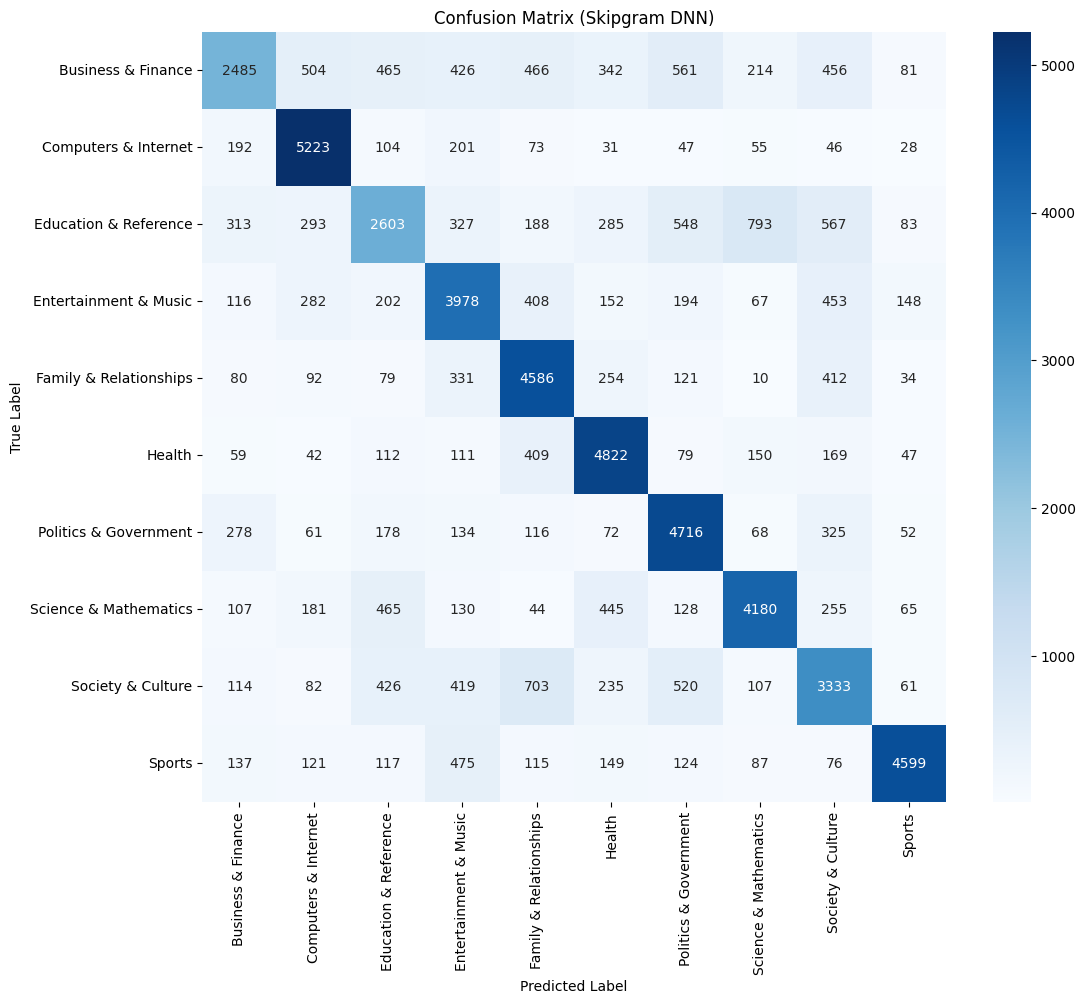


--- Summary of DNN Model with Skipgram Embeddings ---
The best DNN model using Skipgram embeddings achieved a Test Accuracy of 0.6754 and a Macro F1-score of 0.6696.
DNN with Skipgram Embeddings: Accuracy = 0.6754, Macro F1 = 0.6696


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Build the best model with the optimal hyperparameters
print("Building the final DNN model with best Skipgram hyperparameters...")
best_skipgram_model = tuner_skipgram.hypermodel.build(best_hps_skipgram)

checkpoint_path_skipgram = 'best_model_skipgram.keras'
model_checkpoint_skipgram = ModelCheckpoint(
    checkpoint_path_skipgram,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print(f"\nTraining the final DNN model on the full training data with Skipgram embeddings (saving best model to '{checkpoint_path_skipgram}')...")
history_final_skipgram = best_skipgram_model.fit(
    X_train_skipgram,
    y_train_cat_skipgram,
    epochs=50, # Set a reasonably high number, EarlyStopping will stop it
    validation_split=0.2, # Use a validation split for early stopping
    callbacks=[early_stop, model_checkpoint_skipgram],
    verbose=1
)

# Load the best model weights
print(f"\nLoading the best model weights from '{checkpoint_path_skipgram}'...")
final_skipgram_model = tf.keras.models.load_model(checkpoint_path_skipgram)

# --- Evaluate Final DNN Model ---
print("\n--- Evaluating Final DNN Model with Skipgram Embeddings ---")

# Evaluate on the test set
loss_test_skipgram, accuracy_test_skipgram = final_skipgram_model.evaluate(X_test_skipgram, y_test_cat_skipgram, verbose=0)
print(f"Test Accuracy (Skipgram DNN): {accuracy_test_skipgram:.4f}")

# Make predictions
y_pred_probs_skipgram = final_skipgram_model.predict(X_test_skipgram)
y_pred_skipgram = np.argmax(y_pred_probs_skipgram, axis=1)

# Calculate F1-score (macro)
f1_macro_skipgram = f1_score(y_test, y_pred_skipgram, average='macro')
print(f"Test F1-score (Macro, Skipgram DNN): {f1_macro_skipgram:.4f}")

# Display Classification Report
print("\nClassification Report (Skipgram DNN):")
print(classification_report(y_test, y_pred_skipgram, target_names=le.classes_))

# Display Confusion Matrix
conf_matrix_skipgram = confusion_matrix(y_test, y_pred_skipgram)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_skipgram, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (Skipgram DNN)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Final Task: Summarize Results ---
print("\n--- Summary of DNN Model with Skipgram Embeddings ---")
print(f"The best DNN model using Skipgram embeddings achieved a Test Accuracy of {accuracy_test_skipgram:.4f} and a Macro F1-score of {f1_macro_skipgram:.4f}.")


print(f"DNN with Skipgram Embeddings: Accuracy = {accuracy_test_skipgram:.4f}, Macro F1 = {f1_macro_skipgram:.4f}")


# SimpleRNN

In [ ]:
print("Reshaping Skipgram embeddings for RNN input...")

# Reshape X_train_skipgram
X_train_skipgram_reshaped = np.expand_dims(X_train_skipgram, axis=1)

# Reshape X_test_skipgram
X_test_skipgram_reshaped = np.expand_dims(X_test_skipgram, axis=1)

print("Reshaping complete. Displaying new shapes:")
print(f"New shape of X_train_skipgram: {X_train_skipgram_reshaped.shape}")
print(f"New shape of X_test_skipgram: {X_test_skipgram_reshaped.shape}")

Reshaping Skipgram embeddings for RNN input...
Reshaping complete. Displaying new shapes:
New shape of X_train_skipgram: (93333, 1, 100)
New shape of X_test_skipgram: (59999, 1, 100)


In [ ]:
print("Defining build_simplernn_model function for KerasTuner...")
def build_simplernn_model(hp):
    model = Sequential()

    # Input layer for SimpleRNN expects 3D shape (batch_size, timesteps, features)
    # Here, timesteps = 1 as each document embedding is a single timestep
    model.add(SimpleRNN(units=hp.Int('rnn_units', min_value=32, max_value=256, step=32),
                        activation='relu',
                        input_shape=(X_train_skipgram_reshaped.shape[1], X_train_skipgram_reshaped.shape[2])))
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Optional dense layer after RNN
    if hp.Boolean('add_dense_layer'):
        model.add(Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
                        activation='relu'))
        model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    model.add(Dense(num_classes, activation='softmax'))

    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("SimpleRNN model builder function defined.")

Defining build_simplernn_model function for KerasTuner...
SimpleRNN model builder function defined.


Hyperparameter Tune

In [ ]:
print("\n=== Tuning SimpleRNN with Skipgram Embeddings ===")
tuner_simplernn = kt.RandomSearch(
    build_simplernn_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuning_dir',
    project_name='simplernn_tuning'
)

print("Performing hyperparameter search for SimpleRNN...")
tuner_simplernn.search(X_train_skipgram_reshaped, y_train_cat_skipgram, epochs=50, validation_split=0.2, callbacks=[early_stop])

best_hps_simplernn = tuner_simplernn.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters for SimpleRNN Model:")
print(best_hps_simplernn.values)

Trial 5 Complete [00h 01m 45s]
val_accuracy: 0.6603096127510071

Best val_accuracy So Far: 0.6763807535171509
Total elapsed time: 00h 17m 46s

Best Hyperparameters for SimpleRNN Model:
{'rnn_units': 160, 'dropout_1': 0.1, 'add_dense_layer': True, 'learning_rate': 0.001, 'dense_units': 32, 'dropout_2': 0.1}


Training with the best parameter

In [ ]:
print("\nTraining Best SimpleRNN Model...")
model_simplernn = tuner_simplernn.hypermodel.build(best_hps_simplernn)

checkpoint_path_simplernn = 'best_model_simplernn.keras'
checkpoint_simplernn = ModelCheckpoint(checkpoint_path_simplernn, monitor='val_accuracy', save_best_only=True, mode='max')

history_simplernn = model_simplernn.fit(X_train_skipgram_reshaped, y_train_cat_skipgram,
                                      epochs=150,
                                      validation_split=0.2,
                                      callbacks=[checkpoint_simplernn])

print("Best SimpleRNN model trained and saved.")


Training Best SimpleRNN Model...
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2334/2334 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.5156 - loss: 1.4952 - val_accuracy: 0.6475 - val_loss: 1.0777
Epoch 2/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6444 - loss: 1.1021 - val_accuracy: 0.6582 - val_loss: 1.0509
Epoch 3/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6528 - loss: 1.0725 - val_accuracy: 0.6600 - val_loss: 1.0389
Epoch 4/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6587 - loss: 1.0543 - val_accuracy: 0.6640 - val_loss: 1.0244
Epoch 5/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6623 - loss: 1.0445 - val_accuracy: 0.6640 - val_loss: 1.0196
Epoch 6/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6648 - loss: 1.0356 - val_accuracy: 0.6686 - val_loss: 1.0116
Epoch 7/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6656 - loss: 1.0279 - val_accuracy: 0.6659 - val_loss: 1.0180
Epoch 8/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6683 - loss: 1.0227 - va

Evaluation of SimpleRNN


Loading the best SimpleRNN model from 'best_model_simplernn.keras'...

--- Evaluating Final SimpleRNN Model with Skipgram Embeddings ---
Test Accuracy (SimpleRNN): 0.6698
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Test F1-score (Macro, SimpleRNN): 0.6637

Classification Report (SimpleRNN):
                        precision    recall  f1-score   support

    Business & Finance       0.66      0.38      0.48      6000
  Computers & Internet       0.75      0.87      0.80      6000
 Education & Reference       0.53      0.44      0.48      6000
 Entertainment & Music       0.59      0.67      0.63      6000
Family & Relationships       0.66      0.76      0.70      5999
                Health       0.72      0.79      0.75      6000
 Politics & Government       0.64      0.79      0.71      6000
 Science & Mathematics       0.73      0.69      0.71      6000
     Society & Culture       0.55      0.55      0.55      6000
                Sports       0.89      0.75      0.82      6000

  

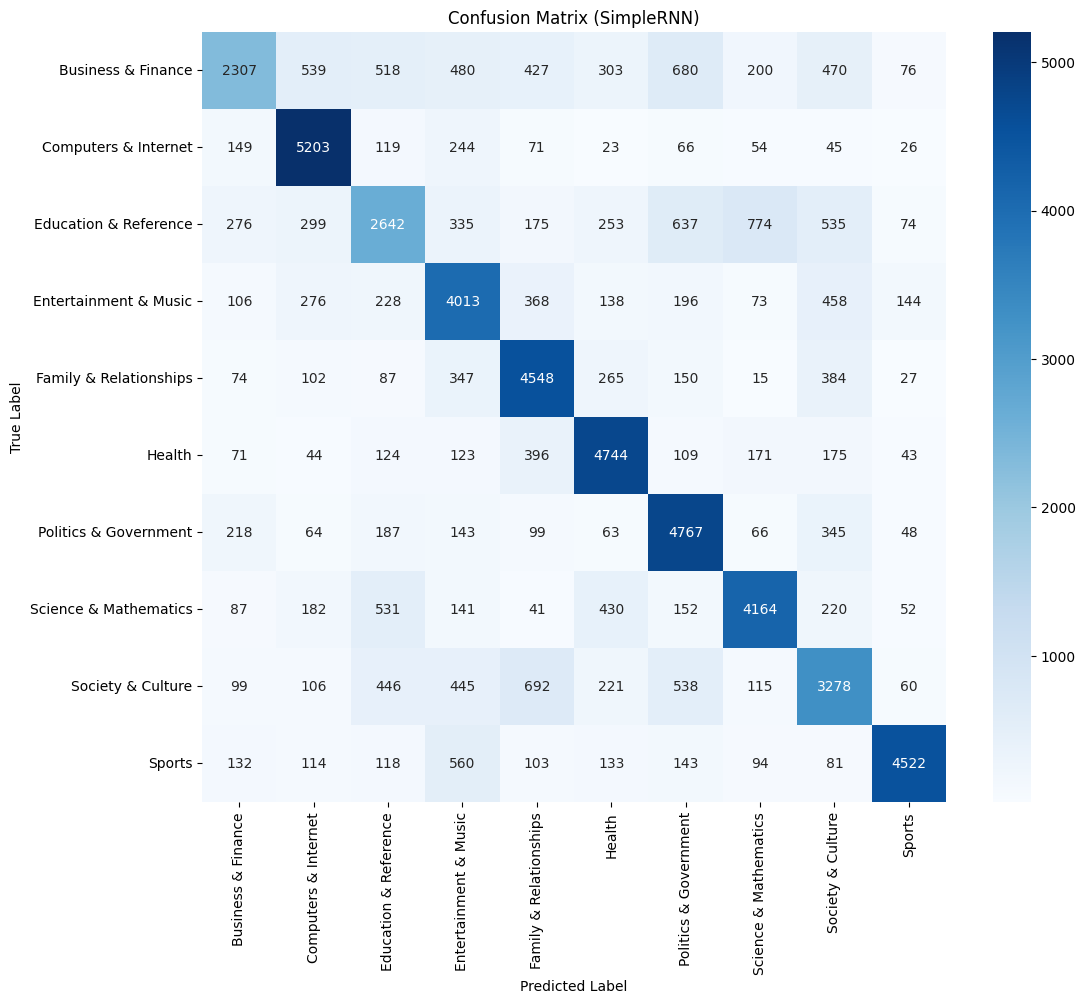


--- Summary of SimpleRNN Model with Skipgram Embeddings ---
The SimpleRNN model using Skipgram embeddings achieved a Test Accuracy of 0.6698 and a Macro F1-score of 0.6637.


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load the best SimpleRNN model
print(f"\nLoading the best SimpleRNN model from '{checkpoint_path_simplernn}'...")
final_simplernn_model = tf.keras.models.load_model(checkpoint_path_simplernn)

# --- Evaluate Final SimpleRNN Model ---
print("\n--- Evaluating Final SimpleRNN Model with Skipgram Embeddings ---")

# Evaluate on the test set
loss_test_simplernn, accuracy_test_simplernn = final_simplernn_model.evaluate(X_test_skipgram_reshaped, y_test_cat_skipgram, verbose=0)
print(f"Test Accuracy (SimpleRNN): {accuracy_test_simplernn:.4f}")

# Make predictions
y_pred_probs_simplernn = final_simplernn_model.predict(X_test_skipgram_reshaped)
y_pred_simplernn = np.argmax(y_pred_probs_simplernn, axis=1)

# Calculate F1-score (macro)
f1_macro_simplernn = f1_score(y_test, y_pred_simplernn, average='macro')
print(f"Test F1-score (Macro, SimpleRNN): {f1_macro_simplernn:.4f}")

# Display Classification Report
print("\nClassification Report (SimpleRNN):")
print(classification_report(y_test, y_pred_simplernn, target_names=le.classes_))

# Display Confusion Matrix
conf_matrix_simplernn = confusion_matrix(y_test, y_pred_simplernn)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_simplernn, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (SimpleRNN)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n--- Summary of SimpleRNN Model with Skipgram Embeddings ---")
print(f"The SimpleRNN model using Skipgram embeddings achieved a Test Accuracy of {accuracy_test_simplernn:.4f} and a Macro F1-score of {f1_macro_simplernn:.4f}.")

# GRU

In [ ]:
print("Defining build_gru_model function for KerasTuner...")
def build_gru_model(hp):
    model = Sequential()

    # GRU layer with tunable units
    # Use fixed input shape based on vector_size (global) which is 100
    model.add(GRU(units=hp.Int('gru_units', min_value=32, max_value=256, step=32),
                  activation='relu',
                  input_shape=(1, vector_size))) # Assuming vector_size is defined globally

    # Dropout after GRU layer
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Optional dense layer
    if hp.Boolean('add_dense_layer'):
        model.add(Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
                        activation='relu'))
        model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(num_classes, activation='softmax')) # Assuming num_classes is defined globally

    # Compile model with tunable learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("GRU model builder function defined.")

Defining build_gru_model function for KerasTuner...
GRU model builder function defined.


Hyperparameter Tune



In [ ]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Redefine early_stop
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


X_train_skipgram_reshaped = np.expand_dims(X_train_skipgram, axis=1)

print("\n=== Tuning GRU with Skipgram Embeddings ===")
tuner_gru = kt.RandomSearch(
    build_gru_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuning_dir',
    project_name='gru_tuning'
)

print("Performing hyperparameter search for GRU...")
tuner_gru.search(X_train_skipgram_reshaped, y_train_cat_skipgram, epochs=50, validation_split=0.2, callbacks=[early_stop])

best_hps_gru = tuner_gru.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters for GRU Model:")
print(best_hps_gru.values)

Trial 5 Complete [00h 01m 47s]
val_accuracy: 0.6670059561729431

Best val_accuracy So Far: 0.6698987483978271
Total elapsed time: 00h 22m 57s

Best Hyperparameters for GRU Model:
{'gru_units': 64, 'dropout_1': 0.2, 'add_dense_layer': True, 'learning_rate': 0.0001, 'dense_units': 64, 'dropout_2': 0.1}


Training GRU with the best parameter

In [ ]:
print("\nTraining Best GRU Model...")
model_gru = tuner_gru.hypermodel.build(best_hps_gru)

checkpoint_path_gru = 'best_model_gru.h5' # Changed to .h5 format
checkpoint_gru = ModelCheckpoint(checkpoint_path_gru, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

history_gru = model_gru.fit(X_train_skipgram_reshaped, y_train_cat_skipgram,
                            epochs=150,
                            validation_split=0.2,
                            callbacks=[ checkpoint_gru]) # Added early_stop callback

print("Best GRU model trained and saved.")


Training Best GRU Model...
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2334/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2755 - loss: 2.1617
Epoch 1: val_accuracy improved from -inf to 0.54160, saving model to best_model_gru.h5


2334/2334 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.2755 - loss: 2.1616 - val_accuracy: 0.5416 - val_loss: 1.4911
Epoch 2/150
2326/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5135 - loss: 1.4832
Epoch 2: val_accuracy improved from 0.54160 to 0.59072, saving model to best_model_gru.h5


2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.5136 - loss: 1.4829 - val_accuracy: 0.5907 - val_loss: 1.2814
Epoch 3/150
2326/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5643 - loss: 1.3242
Epoch 3: val_accuracy improved from 0.59072 to 0.61183, saving model to best_model_gru.h5


...

2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6746 - loss: 1.0017 - val_accuracy: 0.6738 - val_loss: 0.9926
Epoch 95/150
2323/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6737 - loss: 1.0056
Epoch 95: val_accuracy did not improve from 0.67381
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6737 - loss: 1.0056 - val_accuracy: 0.6732 - val_loss: 0.9936
Epoch 96/150
2320/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6730 - loss: 1.0017
Epoch 96: val_accuracy did not improve from 0.67381
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6730 - loss: 1.0017 - val_accuracy: 0.6733 - val_loss: 0.9920
Epoch 97/150
2329/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6748 - loss: 1.0008
Epoch 97: val_accuracy did not improve from 0.67381
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6748 - loss: 1.0008 - val_accuracy: 0.6731 - val_loss: 0.9945
Epoch 98/150
2327/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6722 - loss: 1.0011
Epoch 98

2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6739 - loss: 1.0005 - val_accuracy: 0.6747 - val_loss: 0.9916
Epoch 101/150
2330/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6762 - loss: 0.9989
Epoch 101: val_accuracy did not improve from 0.67472
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6762 - loss: 0.9989 - val_accuracy: 0.6739 - val_loss: 0.9911
Epoch 102/150
2316/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6755 - loss: 0.9986
Epoch 102: val_accuracy did not improve from 0.67472
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6756 - loss: 0.9985 - val_accuracy: 0.6738 - val_loss: 0.9923
Epoch 103/150
2323/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6734 - loss: 1.0000
Epoch 103: val_accuracy did not improve from 0.67472
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6734 - loss: 1.0000 - val_accuracy: 0.6746 - val_loss: 0.9912
Epoch 104/150
2316/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6730 - loss: 0.9988
E

2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6741 - loss: 1.0001 - val_accuracy: 0.6749 - val_loss: 0.9908
Epoch 109/150
2327/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6756 - loss: 0.9996
Epoch 109: val_accuracy improved from 0.67488 to 0.67504, saving model to best_model_gru.h5


2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6756 - loss: 0.9995 - val_accuracy: 0.6750 - val_loss: 0.9905
Epoch 110/150
2328/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6772 - loss: 0.9960
Epoch 110: val_accuracy did not improve from 0.67504
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6772 - loss: 0.9960 - val_accuracy: 0.6740 - val_loss: 0.9907
Epoch 111/150
2322/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6777 - loss: 0.9954
Epoch 111: val_accuracy did not improve from 0.67504
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6777 - loss: 0.9954 - val_accuracy: 0.6743 - val_loss: 0.9906
Epoch 112/150
2333/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6770 - loss: 0.9937
Epoch 112: val_accuracy did not improve from 0.67504
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6770 - loss: 0.9937 - val_accuracy: 0.6733 - val_loss: 0.9914
Epoch 113/150
2327/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6757 - loss: 0.9949


2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6802 - loss: 0.9885 - val_accuracy: 0.6756 - val_loss: 0.9886
Epoch 140/150
2325/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6793 - loss: 0.9897
Epoch 140: val_accuracy did not improve from 0.67558
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6793 - loss: 0.9897 - val_accuracy: 0.6748 - val_loss: 0.9871
Epoch 141/150
2332/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6786 - loss: 0.9871
Epoch 141: val_accuracy did not improve from 0.67558
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6786 - loss: 0.9871 - val_accuracy: 0.6740 - val_loss: 0.9876
Epoch 142/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6782 - loss: 0.9878
Epoch 142: val_accuracy did not improve from 0.67558
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6782 - loss: 0.9878 - val_accuracy: 0.6754 - val_loss: 0.9872
Epoch 143/150
2332/2334 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6796 - loss: 0.9865
E

Evaluation


Loading the best GRU model from 'best_model_gru.h5'...

--- Evaluating Final GRU Model with Skipgram Embeddings ---
Test Accuracy (GRU): 0.6682
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Test F1-score (Macro, GRU): 0.6638

Classification Report (GRU):
                        precision    recall  f1-score   support

    Business & Finance       0.62      0.43      0.50      6000
  Computers & Internet       0.78      0.86      0.82      6000
 Education & Reference       0.52      0.43      0.48      6000
 Entertainment & Music       0.61      0.64      0.63      6000
Family & Relationships       0.65      0.76      0.70      5999
                Health       0.75      0.77      0.76      6000
 Politics & Government       0.63      0.80      0.70      6000
 Science & Mathematics       0.71      0.70      0.70      6000
     Society & Culture       0.53      0.54      0.54      6000
                Sports       0.88      0.76      0.82      6000

              accuracy                   

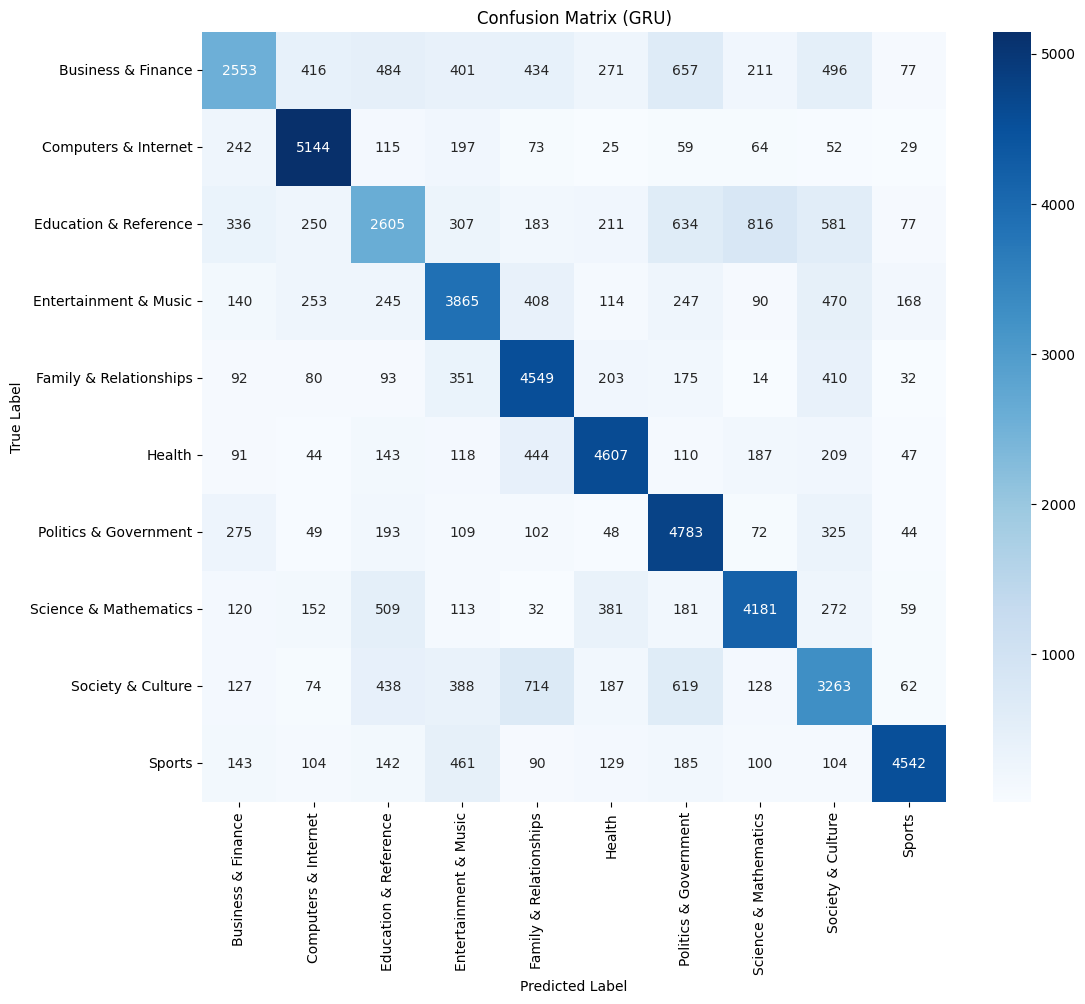


--- Summary of GRU Model with Skipgram Embeddings ---
The GRU model using Skipgram embeddings achieved a Test Accuracy of 0.6682 and a Macro F1-score of 0.6638.


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import ModelCheckpoint

# Define checkpoint path for GRU model (moved from previous cell)
checkpoint_path_gru = 'best_model_gru.h5' # Changed to .h5 to match the saving format

# Redefine X_test_skipgram_reshaped if it's not in scope
X_test_skipgram_reshaped = np.expand_dims(X_test_skipgram, axis=1)

# Load the best GRU model
print(f"\nLoading the best GRU model from '{checkpoint_path_gru}'...")
final_gru_model = tf.keras.models.load_model(checkpoint_path_gru)

# --- Evaluate Final GRU Model ---
print("\n--- Evaluating Final GRU Model with Skipgram Embeddings ---")

# Evaluate on the test set
loss_test_gru, accuracy_test_gru = final_gru_model.evaluate(X_test_skipgram_reshaped, y_test_cat_skipgram, verbose=0)
print(f"Test Accuracy (GRU): {accuracy_test_gru:.4f}")

# Make predictions
y_pred_probs_gru = final_gru_model.predict(X_test_skipgram_reshaped)
y_pred_gru = np.argmax(y_pred_probs_gru, axis=1)

# Calculate F1-score (macro)
f1_macro_gru = f1_score(y_test, y_pred_gru, average='macro')
print(f"Test F1-score (Macro, GRU): {f1_macro_gru:.4f}")

# Display Classification Report
print("\nClassification Report (GRU):")
print(classification_report(y_test, y_pred_gru, target_names=le.classes_))

# Display Confusion Matrix
conf_matrix_gru = confusion_matrix(y_test, y_pred_gru)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_gru, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (GRU)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n--- Summary of GRU Model with Skipgram Embeddings ---")
print(f"The GRU model using Skipgram embeddings achieved a Test Accuracy of {accuracy_test_gru:.4f} and a Macro F1-score of {f1_macro_gru:.4f}.")

# LSTM

In [ ]:
print("Defining build_lstm_model function for KerasTuner...")
def build_lstm_model(hp):
    model = Sequential()

    # LSTM layer with tunable units
    model.add(LSTM(units=hp.Int('lstm_units', min_value=32, max_value=256, step=32),
                   activation='relu',
                   input_shape=(X_train_skipgram_reshaped.shape[1], X_train_skipgram_reshaped.shape[2])))

    # Dropout after LSTM layer
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Optional dense layer
    if hp.Boolean('add_dense_layer'):
        model.add(Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
                        activation='relu'))
        model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(num_classes, activation='softmax')) # Assuming num_classes is defined globally

    # Compile model with tunable learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("LSTM model builder function defined.")

Defining build_lstm_model function for KerasTuner...
LSTM model builder function defined.


Hyperparameter Tune of LSTM

In [ ]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Redefine early_stop
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


X_train_skipgram_reshaped = np.expand_dims(X_train_skipgram, axis=1)

print("\n=== Tuning LSTM with Skipgram Embeddings ===")
tuner_lstm = kt.RandomSearch(
    build_lstm_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuning_dir',
    project_name='lstm_tuning'
)

print("Performing hyperparameter search for LSTM...")
tuner_lstm.search(X_train_skipgram_reshaped, y_train_cat_skipgram, epochs=50, validation_split=0.2, callbacks=[early_stop])

best_hps_lstm = tuner_lstm.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters for LSTM Model:")
print(best_hps_lstm.values)

Trial 5 Complete [00h 03m 03s]
val_accuracy: 0.6722558736801147

Best val_accuracy So Far: 0.6772379279136658
Total elapsed time: 00h 23m 42s

Best Hyperparameters for LSTM Model:
{'lstm_units': 256, 'dropout_1': 0.30000000000000004, 'add_dense_layer': False, 'learning_rate': 0.001, 'dense_units': 64, 'dropout_2': 0.5}


Train with the best LSTM model

In [ ]:
print("\nTraining Best LSTM Model...")
model_lstm = tuner_lstm.hypermodel.build(best_hps_lstm)

checkpoint_path_lstm = 'best_model_lstm.keras'
checkpoint_lstm = ModelCheckpoint(checkpoint_path_lstm, monitor='val_accuracy', save_best_only=True, mode='max')

history_lstm = model_lstm.fit(X_train_skipgram_reshaped, y_train_cat_skipgram,
                                      epochs=150,
                                      validation_split=0.2,
                                      callbacks=[checkpoint_lstm])

print("Best LSTM model trained and saved.")


Training Best LSTM Model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.5176 - loss: 1.5158 - val_accuracy: 0.6479 - val_loss: 1.0861
Epoch 2/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6460 - loss: 1.0922 - val_accuracy: 0.6566 - val_loss: 1.0485
Epoch 3/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6564 - loss: 1.0602 - val_accuracy: 0.6608 - val_loss: 1.0365
Epoch 4/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6602 - loss: 1.0436 - val_accuracy: 0.6618 - val_loss: 1.0262
Epoch 5/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6631 - loss: 1.0342 - val_accuracy: 0.6648 - val_loss: 1.0171
Epoch 6/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6639 - loss: 1.0272 - val_accuracy: 0.6661 - val_loss: 1.0133
Epoch 7/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6677 - loss: 1.0213 - val_accuracy: 0.6665 - val_loss: 1.0130
Epoch 8/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6699 - loss: 

Evaluation


Loading the best LSTM model from 'best_model_lstm.keras'...

--- Evaluating Final LSTM Model with Skipgram Embeddings ---
Test Accuracy (LSTM): 0.6685
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Test F1-score (Macro, LSTM): 0.6673

Classification Report (LSTM):
                        precision    recall  f1-score   support

    Business & Finance       0.53      0.46      0.49      6000
  Computers & Internet       0.80      0.84      0.82      6000
 Education & Reference       0.52      0.47      0.49      6000
 Entertainment & Music       0.60      0.66      0.63      6000
Family & Relationships       0.70      0.72      0.71      5999
                Health       0.75      0.77      0.76      6000
 Politics & Government       0.66      0.79      0.72      6000
 Science & Mathematics       0.71      0.70      0.71      6000
     Society & Culture       0.54      0.55      0.55      6000
                Sports       0.91      0.73      0.81      6000

              accuracy          

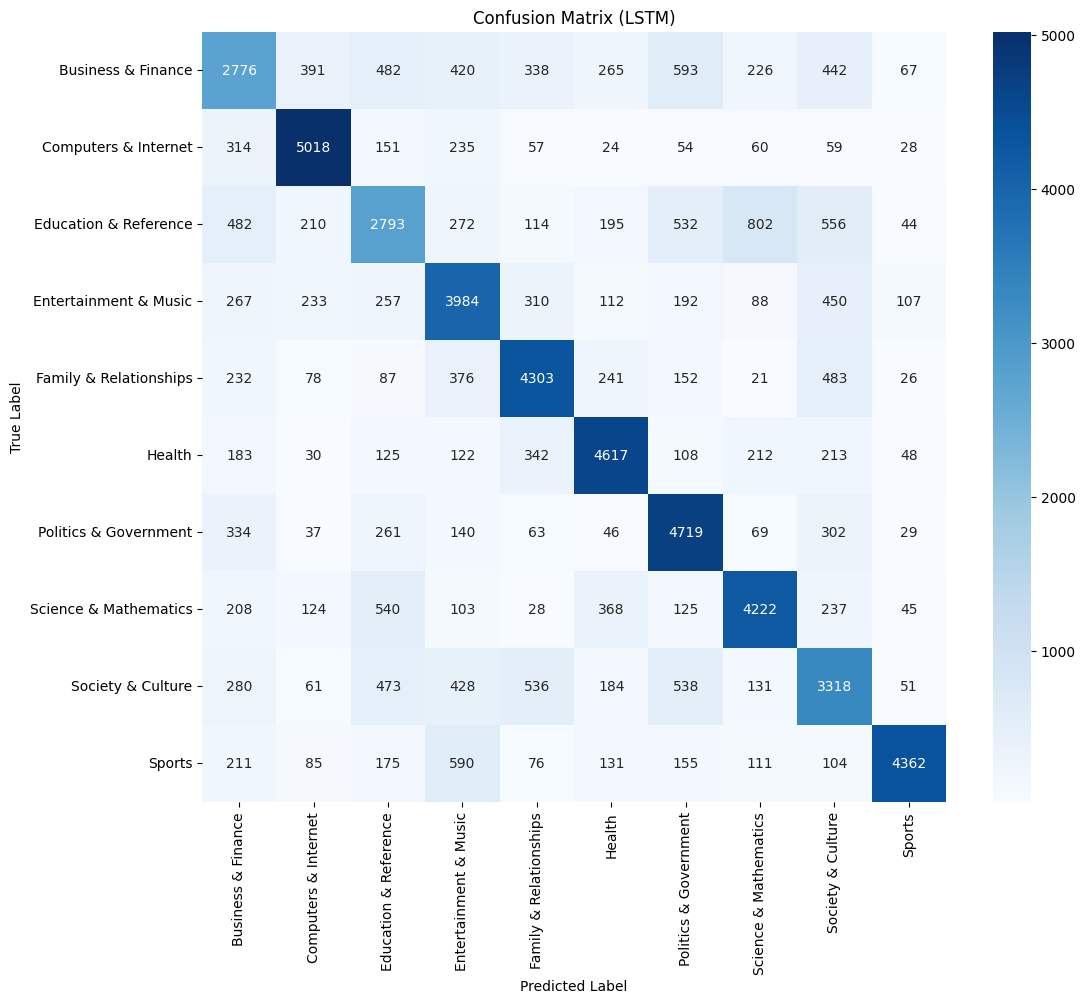


--- Summary of LSTM Model with Skipgram Embeddings ---
The LSTM model using Skipgram embeddings achieved a Test Accuracy of 0.6685 and a Macro F1-score of 0.6673.


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import ModelCheckpoint

# Define checkpoint path for LSTM model
checkpoint_path_lstm = 'best_model_lstm.keras'

# Load the best LSTM model
print(f"\nLoading the best LSTM model from '{checkpoint_path_lstm}'...")
final_lstm_model = tf.keras.models.load_model(checkpoint_path_lstm)

# --- Evaluate Final LSTM Model ---
print("\n--- Evaluating Final LSTM Model with Skipgram Embeddings ---")

# Evaluate on the test set
loss_test_lstm, accuracy_test_lstm = final_lstm_model.evaluate(X_test_skipgram_reshaped, y_test_cat_skipgram, verbose=0)
print(f"Test Accuracy (LSTM): {accuracy_test_lstm:.4f}")

# Make predictions
y_pred_probs_lstm = final_lstm_model.predict(X_test_skipgram_reshaped)
y_pred_lstm = np.argmax(y_pred_probs_lstm, axis=1)

# Calculate F1-score (macro)
f1_macro_lstm = f1_score(y_test, y_pred_lstm, average='macro')
print(f"Test F1-score (Macro, LSTM): {f1_macro_lstm:.4f}")

# Display Classification Report
print("\nClassification Report (LSTM):")
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))

# Display Confusion Matrix
conf_matrix_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (LSTM)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n--- Summary of LSTM Model with Skipgram Embeddings ---")
print(f"The LSTM model using Skipgram embeddings achieved a Test Accuracy of {accuracy_test_lstm:.4f} and a Macro F1-score of {f1_macro_lstm:.4f}.")

# Bidirectional SimpleRNN

In [ ]:
print("Defining build_bidirectional_simplernn_model function for KerasTuner...")
def build_bidirectional_simplernn_model(hp):
    model = Sequential()

    # Bidirectional SimpleRNN layer with tunable units
    model.add(Bidirectional(SimpleRNN(units=hp.Int('rnn_units', min_value=32, max_value=256, step=32),
                                      activation='relu'),
                            input_shape=(X_train_skipgram_reshaped.shape[1], X_train_skipgram_reshaped.shape[2])))

    # Dropout after Bidirectional RNN layer
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Optional dense layer
    if hp.Boolean('add_dense_layer'):
        model.add(Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
                        activation='relu'))
        model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(num_classes, activation='softmax')) # Assuming num_classes is defined globally

    # Compile model with tunable learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("Bidirectional SimpleRNN model builder function defined.")

Defining build_bidirectional_simplernn_model function for KerasTuner...
Bidirectional SimpleRNN model builder function defined.


Hyperparameter Tune

In [ ]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np # Needed for np.expand_dims

# Redefine early_stop (it's defined in cell 'a7b558c0')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

X_train_skipgram_reshaped = np.expand_dims(X_train_skipgram, axis=1)

print("\n=== Tuning Bidirectional SimpleRNN with Skipgram Embeddings ===")
tuner_bidirectional_simplernn = kt.RandomSearch(
    build_bidirectional_simplernn_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuning_dir',
    project_name='bidirectional_simplernn_tuning'
)

print("Performing hyperparameter search for Bidirectional SimpleRNN...")
tuner_bidirectional_simplernn.search(X_train_skipgram_reshaped, y_train_cat_skipgram, epochs=50, validation_split=0.2, callbacks=[early_stop])

best_hps_bidirectional_simplernn = tuner_bidirectional_simplernn.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters for Bidirectional SimpleRNN Model:")
print(best_hps_bidirectional_simplernn.values)

Trial 5 Complete [00h 02m 46s]
val_accuracy: 0.6718273162841797

Best val_accuracy So Far: 0.6754165291786194
Total elapsed time: 00h 13m 45s

Best Hyperparameters for Bidirectional SimpleRNN Model:
{'rnn_units': 160, 'dropout_1': 0.2, 'add_dense_layer': True, 'learning_rate': 0.001, 'dense_units': 32, 'dropout_2': 0.1}


Train the best model

In [ ]:
print("\nTraining Best Bidirectional SimpleRNN Model...")
model_bidirectional_simplernn = tuner_bidirectional_simplernn.hypermodel.build(best_hps_bidirectional_simplernn)

checkpoint_path_bidirectional_simplernn = 'best_model_bidirectional_simplernn.keras'
checkpoint_bidirectional_simplernn = ModelCheckpoint(checkpoint_path_bidirectional_simplernn, monitor='val_accuracy', save_best_only=True, mode='max')

history_bidirectional_simplernn = model_bidirectional_simplernn.fit(X_train_skipgram_reshaped, y_train_cat_skipgram,
                                      epochs=150,
                                      validation_split=0.2,
                                      callbacks=[checkpoint_bidirectional_simplernn])

print("Best Bidirectional SimpleRNN model trained and saved.")


Training Best Bidirectional SimpleRNN Model...
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2334/2334 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.5219 - loss: 1.4647 - val_accuracy: 0.6509 - val_loss: 1.0729
Epoch 2/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6454 - loss: 1.1000 - val_accuracy: 0.6593 - val_loss: 1.0414
Epoch 3/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6544 - loss: 1.0718 - val_accuracy: 0.6641 - val_loss: 1.0270
Epoch 4/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6561 - loss: 1.0571 - val_accuracy: 0.6633 - val_loss: 1.0244
Epoch 5/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6617 - loss: 1.0468 - val_accuracy: 0.6672 - val_loss: 1.0131
Epoch 6/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6652 - loss: 1.0344 - val_accuracy: 0.6660 - val_loss: 1.0134
Epoch 7/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6644 - loss: 1.0291 - val_accuracy: 0.6722 - val_loss: 1.0021
Epoch 8/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6674 - loss: 1.0216 - va

Evaluation


Loading the best Bidirectional SimpleRNN model from 'best_model_bidirectional_simplernn.keras'...

--- Evaluating Final Bidirectional SimpleRNN Model with Skipgram Embeddings ---
Test Accuracy (Bidirectional SimpleRNN): 0.6686
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Test F1-score (Macro, Bidirectional SimpleRNN): 0.6659

Classification Report (Bidirectional SimpleRNN):
                        precision    recall  f1-score   support

    Business & Finance       0.65      0.40      0.50      6000
  Computers & Internet       0.78      0.85      0.81      6000
 Education & Reference       0.49      0.49      0.49      6000
 Entertainment & Music       0.57      0.68      0.62      6000
Family & Relationships       0.67      0.74      0.70      5999
                Health       0.76      0.76      0.76      6000
 Politics & Government       0.66      0.79      0.72      6000
 Science & Mathematics       0.72      0.69      0.71      6000
     Society & Culture       0.53      0.54    

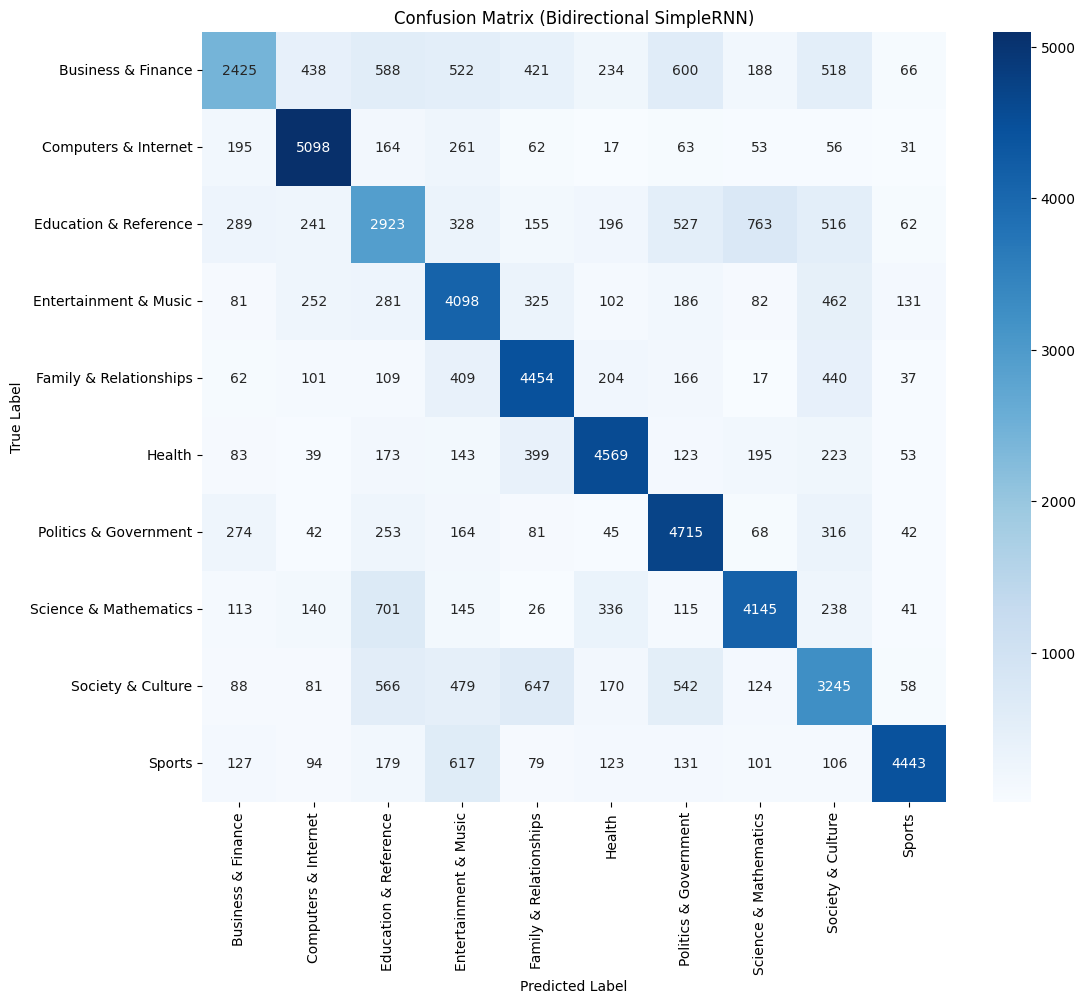


--- Summary of Bidirectional SimpleRNN Model with Skipgram Embeddings ---
The Bidirectional SimpleRNN model using Skipgram embeddings achieved a Test Accuracy of 0.6686 and a Macro F1-score of 0.6659.


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import ModelCheckpoint

# Define checkpoint path for Bidirectional SimpleRNN model
checkpoint_path_bidirectional_simplernn = 'best_model_bidirectional_simplernn.keras'

# Load the best Bidirectional SimpleRNN model
print(f"\nLoading the best Bidirectional SimpleRNN model from '{checkpoint_path_bidirectional_simplernn}'...")
final_bidirectional_simplernn_model = tf.keras.models.load_model(checkpoint_path_bidirectional_simplernn)

# --- Evaluate Final Bidirectional SimpleRNN Model ---
print("\n--- Evaluating Final Bidirectional SimpleRNN Model with Skipgram Embeddings ---")

# Evaluate on the test set
loss_test_bidirectional_simplernn, accuracy_test_bidirectional_simplernn = final_bidirectional_simplernn_model.evaluate(X_test_skipgram_reshaped, y_test_cat_skipgram, verbose=0)
print(f"Test Accuracy (Bidirectional SimpleRNN): {accuracy_test_bidirectional_simplernn:.4f}")

# Make predictions
y_pred_probs_bidirectional_simplernn = final_bidirectional_simplernn_model.predict(X_test_skipgram_reshaped)
y_pred_bidirectional_simplernn = np.argmax(y_pred_probs_bidirectional_simplernn, axis=1)

# Calculate F1-score (macro)
f1_macro_bidirectional_simplernn = f1_score(y_test, y_pred_bidirectional_simplernn, average='macro')
print(f"Test F1-score (Macro, Bidirectional SimpleRNN): {f1_macro_bidirectional_simplernn:.4f}")

# Display Classification Report
print("\nClassification Report (Bidirectional SimpleRNN):")
print(classification_report(y_test, y_pred_bidirectional_simplernn, target_names=le.classes_))

# Display Confusion Matrix
conf_matrix_bidirectional_simplernn = confusion_matrix(y_test, y_pred_bidirectional_simplernn)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_bidirectional_simplernn, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (Bidirectional SimpleRNN)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n--- Summary of Bidirectional SimpleRNN Model with Skipgram Embeddings ---")
print(f"The Bidirectional SimpleRNN model using Skipgram embeddings achieved a Test Accuracy of {accuracy_test_bidirectional_simplernn:.4f} and a Macro F1-score of {f1_macro_bidirectional_simplernn:.4f}.")

# Bidirectional GRU

In [ ]:
print("Defining build_bidirectional_gru_model function for KerasTuner...")
def build_bidirectional_gru_model(hp):
    model = Sequential()

    # Bidirectional GRU layer with tunable units
    model.add(Bidirectional(GRU(units=hp.Int('gru_units', min_value=32, max_value=256, step=32),
                                  activation='relu'),
                            input_shape=(X_train_skipgram_reshaped.shape[1], X_train_skipgram_reshaped.shape[2])))

    # Dropout after Bidirectional GRU layer
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Optional dense layer
    if hp.Boolean('add_dense_layer'):
        model.add(Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
                        activation='relu'))
        model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(num_classes, activation='softmax')) # Assuming num_classes is defined globally

    # Compile model with tunable learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("Bidirectional GRU model builder function defined.")

Defining build_bidirectional_gru_model function for KerasTuner...
Bidirectional GRU model builder function defined.


Hyperparameter Tune

In [ ]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np # Ensure numpy is imported if not already in scope

# Redefine early_stop (it's defined in cell 'a7b558c0' and used in earlier tuning steps)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

X_train_skipgram_reshaped = np.expand_dims(X_train_skipgram, axis=1)

print("\n=== Tuning Bidirectional GRU with Skipgram Embeddings ===")
tuner_bidirectional_gru = kt.RandomSearch(
    build_bidirectional_gru_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuning_dir',
    project_name='bidirectional_gru_tuning'
)

print("Performing hyperparameter search for Bidirectional GRU...")
tuner_bidirectional_gru.search(X_train_skipgram_reshaped, y_train_cat_skipgram, epochs=50, validation_split=0.2, callbacks=[early_stop])

best_hps_bidirectional_gru = tuner_bidirectional_gru.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters for Bidirectional GRU Model:")
print(best_hps_bidirectional_gru.values)

Trial 5 Complete [00h 04m 16s]
val_accuracy: 0.676487922668457

Best val_accuracy So Far: 0.6773986220359802
Total elapsed time: 00h 16m 46s

Best Hyperparameters for Bidirectional GRU Model:
{'gru_units': 64, 'dropout_1': 0.30000000000000004, 'add_dense_layer': True, 'learning_rate': 0.001, 'dense_units': 64, 'dropout_2': 0.2}


Train with the best hyperparameter

In [ ]:
print("\nTraining Best Bidirectional GRU Model...")
model_bidirectional_gru = tuner_bidirectional_gru.hypermodel.build(best_hps_bidirectional_gru)

checkpoint_path_bidirectional_gru = 'best_model_bidirectional_gru.keras'
checkpoint_bidirectional_gru = ModelCheckpoint(checkpoint_path_bidirectional_gru, monitor='val_accuracy', save_best_only=True, mode='max')

history_bidirectional_gru = model_bidirectional_gru.fit(X_train_skipgram_reshaped, y_train_cat_skipgram,
                                      epochs=150,
                                      validation_split=0.2,
                                      callbacks=[checkpoint_bidirectional_gru])

print("Best Bidirectional GRU model trained and saved.")


Training Best Bidirectional GRU Model...
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2334/2334 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.4764 - loss: 1.5599 - val_accuracy: 0.6445 - val_loss: 1.0869
Epoch 2/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6350 - loss: 1.1369 - val_accuracy: 0.6548 - val_loss: 1.0549
Epoch 3/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.6440 - loss: 1.1077 - val_accuracy: 0.6620 - val_loss: 1.0353
Epoch 4/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6501 - loss: 1.0880 - val_accuracy: 0.6659 - val_loss: 1.0245
Epoch 5/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6556 - loss: 1.0743 - val_accuracy: 0.6648 - val_loss: 1.0250
Epoch 6/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6573 - loss: 1.0678 - val_accuracy: 0.6649 - val_loss: 1.0160
Epoch 7/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.6595 - loss: 1.0593 - val_accuracy: 0.6662 - val_loss: 1.0097
Epoch 8/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6603 - loss: 1.0535 - val

Evaluation


Loading the best Bidirectional GRU model from 'best_model_bidirectional_gru.keras'...

--- Evaluating Final Bidirectional GRU Model with Skipgram Embeddings ---
Test Accuracy (Bidirectional GRU): 0.6696
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Test F1-score (Macro, Bidirectional GRU): 0.6650

Classification Report (Bidirectional GRU):
                        precision    recall  f1-score   support

    Business & Finance       0.67      0.39      0.49      6000
  Computers & Internet       0.78      0.85      0.82      6000
 Education & Reference       0.53      0.46      0.49      6000
 Entertainment & Music       0.59      0.67      0.63      6000
Family & Relationships       0.64      0.76      0.70      5999
                Health       0.75      0.77      0.76      6000
 Politics & Government       0.63      0.80      0.70      6000
 Science & Mathematics       0.73      0.69      0.71      6000
     Society & Culture       0.53      0.55      0.54      6000
                Spo

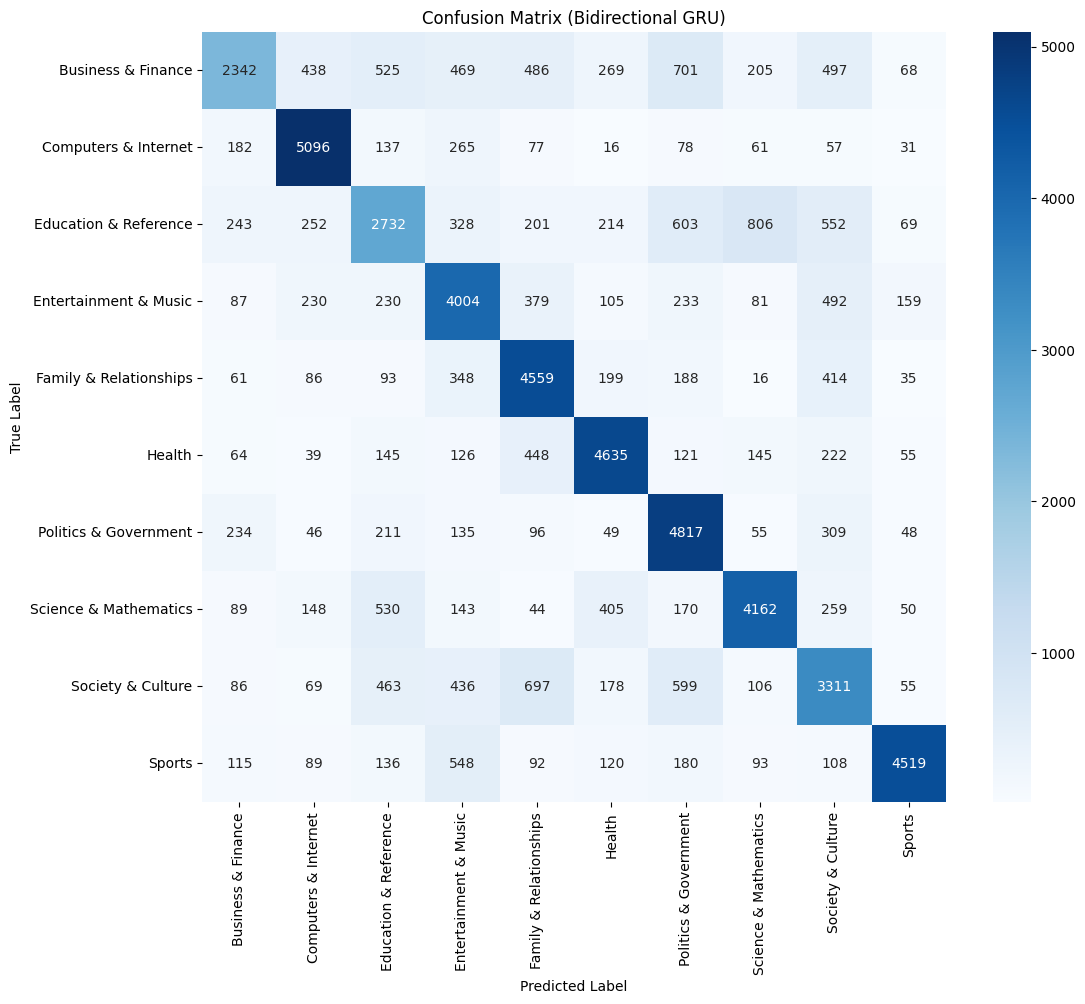


--- Summary of Bidirectional GRU Model with Skipgram Embeddings ---
The Bidirectional GRU model using Skipgram embeddings achieved a Test Accuracy of 0.6696 and a Macro F1-score of 0.6650.


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define checkpoint path for Bidirectional GRU model
checkpoint_path_bidirectional_gru = 'best_model_bidirectional_gru.keras'

# Load the best Bidirectional GRU model
print(f"\nLoading the best Bidirectional GRU model from '{checkpoint_path_bidirectional_gru}'...")
final_bidirectional_gru_model = tf.keras.models.load_model(checkpoint_path_bidirectional_gru)

# --- Evaluate Final Bidirectional GRU Model ---
print("\n--- Evaluating Final Bidirectional GRU Model with Skipgram Embeddings ---")

# Evaluate on the test set
loss_test_bidirectional_gru, accuracy_test_bidirectional_gru = final_bidirectional_gru_model.evaluate(X_test_skipgram_reshaped, y_test_cat_skipgram, verbose=0)
print(f"Test Accuracy (Bidirectional GRU): {accuracy_test_bidirectional_gru:.4f}")

# Make predictions
y_pred_probs_bidirectional_gru = final_bidirectional_gru_model.predict(X_test_skipgram_reshaped)
y_pred_bidirectional_gru = np.argmax(y_pred_probs_bidirectional_gru, axis=1)

# Calculate F1-score (macro)
f1_macro_bidirectional_gru = f1_score(y_test, y_pred_bidirectional_gru, average='macro')
print(f"Test F1-score (Macro, Bidirectional GRU): {f1_macro_bidirectional_gru:.4f}")

# Display Classification Report
print("\nClassification Report (Bidirectional GRU):")
print(classification_report(y_test, y_pred_bidirectional_gru, target_names=le.classes_))

# Display Confusion Matrix
conf_matrix_bidirectional_gru = confusion_matrix(y_test, y_pred_bidirectional_gru)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_bidirectional_gru, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (Bidirectional GRU)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n--- Summary of Bidirectional GRU Model with Skipgram Embeddings ---")
print(f"The Bidirectional GRU model using Skipgram embeddings achieved a Test Accuracy of {accuracy_test_bidirectional_gru:.4f} and a Macro F1-score of {f1_macro_bidirectional_gru:.4f}.")

# BiDirectional LSTM

In [ ]:
print("Defining build_bidirectional_lstm_model function for KerasTuner...")
def build_bidirectional_lstm_model(hp):
    model = Sequential()

    # Bidirectional LSTM layer with tunable units
    model.add(Bidirectional(LSTM(units=hp.Int('lstm_units', min_value=32, max_value=256, step=32),
                                  activation='relu'),
                            input_shape=(X_train_skipgram_reshaped.shape[1], X_train_skipgram_reshaped.shape[2])))

    # Dropout after Bidirectional LSTM layer
    model.add(Dropout(rate=hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))

    # Optional dense layer
    if hp.Boolean('add_dense_layer'):
        model.add(Dense(units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
                        activation='relu'))
        model.add(Dropout(rate=hp.Float('dropout_2', min_value=0.1, max_value=0.5, step=0.1)))

    # Output layer
    model.add(Dense(num_classes, activation='softmax')) # Assuming num_classes is defined globally

    # Compile model with tunable learning rate
    model.compile(optimizer=tf.keras.optimizers.Adam(
                    learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("Bidirectional LSTM model builder function defined.")

Defining build_bidirectional_lstm_model function for KerasTuner...
Bidirectional LSTM model builder function defined.


Hyperparameter Tune

In [ ]:
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np # Ensure numpy is imported if not already in scope
import tensorflow as tf # Import tensorflow with alias tf

# Redefine early_stop
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

X_train_skipgram_reshaped = np.expand_dims(X_train_skipgram, axis=1)

print("\n=== Tuning Bidirectional LSTM with Skipgram Embeddings ===")
tuner_bidirectional_lstm = kt.RandomSearch(
    build_bidirectional_lstm_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuning_dir',
    project_name='bidirectional_lstm_tuning'
)

print("Performing hyperparameter search for Bidirectional LSTM...")
tuner_bidirectional_lstm.search(X_train_skipgram_reshaped, y_train_cat_skipgram, epochs=50, validation_split=0.2, callbacks=[early_stop])

best_hps_bidirectional_lstm = tuner_bidirectional_lstm.get_best_hyperparameters(num_trials=1)[0]

print("\nBest Hyperparameters for Bidirectional LSTM Model:")
print(best_hps_bidirectional_lstm.values)

Trial 5 Complete [00h 03m 12s]
val_accuracy: 0.6714522838592529

Best val_accuracy So Far: 0.6775057315826416
Total elapsed time: 00h 23m 03s

Best Hyperparameters for Bidirectional LSTM Model:
{'lstm_units': 256, 'dropout_1': 0.5, 'add_dense_layer': False, 'learning_rate': 0.001}


Train with the best hyperparameter

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

print("\nTraining Best Bidirectional LSTM Model...")
model_bidirectional_lstm = tuner_bidirectional_lstm.hypermodel.build(best_hps_bidirectional_lstm)

checkpoint_path_bidirectional_lstm = 'best_model_bidirectional_lstm.keras'
checkpoint_bidirectional_lstm = ModelCheckpoint(checkpoint_path_bidirectional_lstm, monitor='val_accuracy', save_best_only=True, mode='max')

history_bidirectional_lstm = model_bidirectional_lstm.fit(X_train_skipgram_reshaped, y_train_cat_skipgram,
                                      epochs=150,
                                      validation_split=0.2,
                                      callbacks=[checkpoint_bidirectional_lstm])

print("Best Bidirectional LSTM model trained and saved.")


Training Best Bidirectional LSTM Model...
Epoch 1/150


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2334/2334 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.5194 - loss: 1.4995 - val_accuracy: 0.6493 - val_loss: 1.0837
Epoch 2/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6463 - loss: 1.0962 - val_accuracy: 0.6550 - val_loss: 1.0524
Epoch 3/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6536 - loss: 1.0690 - val_accuracy: 0.6601 - val_loss: 1.0388
Epoch 4/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6570 - loss: 1.0566 - val_accuracy: 0.6623 - val_loss: 1.0295
Epoch 5/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6593 - loss: 1.0484 - val_accuracy: 0.6628 - val_loss: 1.0239
Epoch 6/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.6603 - loss: 1.0423 - val_accuracy: 0.6613 - val_loss: 1.0262
Epoch 7/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.6633 - loss: 1.0384 - val_accuracy: 0.6651 - val_loss: 1.0188
Epoch 8/150
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6643 - loss: 1.0311 - va

Evaluation


Loading the best Bidirectional LSTM model from 'best_model_bidirectional_lstm.keras'...

--- Evaluating Final Bidirectional LSTM Model with Skipgram Embeddings ---
Test Accuracy (Bidirectional LSTM): 0.6712
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Test F1-score (Macro, Bidirectional LSTM): 0.6688

Classification Report (Bidirectional LSTM):
                        precision    recall  f1-score   support

    Business & Finance       0.58      0.44      0.50      6000
  Computers & Internet       0.80      0.85      0.82      6000
 Education & Reference       0.52      0.46      0.49      6000
 Entertainment & Music       0.55      0.70      0.62      6000
Family & Relationships       0.67      0.74      0.71      5999
                Health       0.76      0.77      0.76      6000
 Politics & Government       0.70      0.76      0.73      6000
 Science & Mathematics       0.70      0.71      0.71      6000
     Society & Culture       0.56      0.54      0.55      6000
             

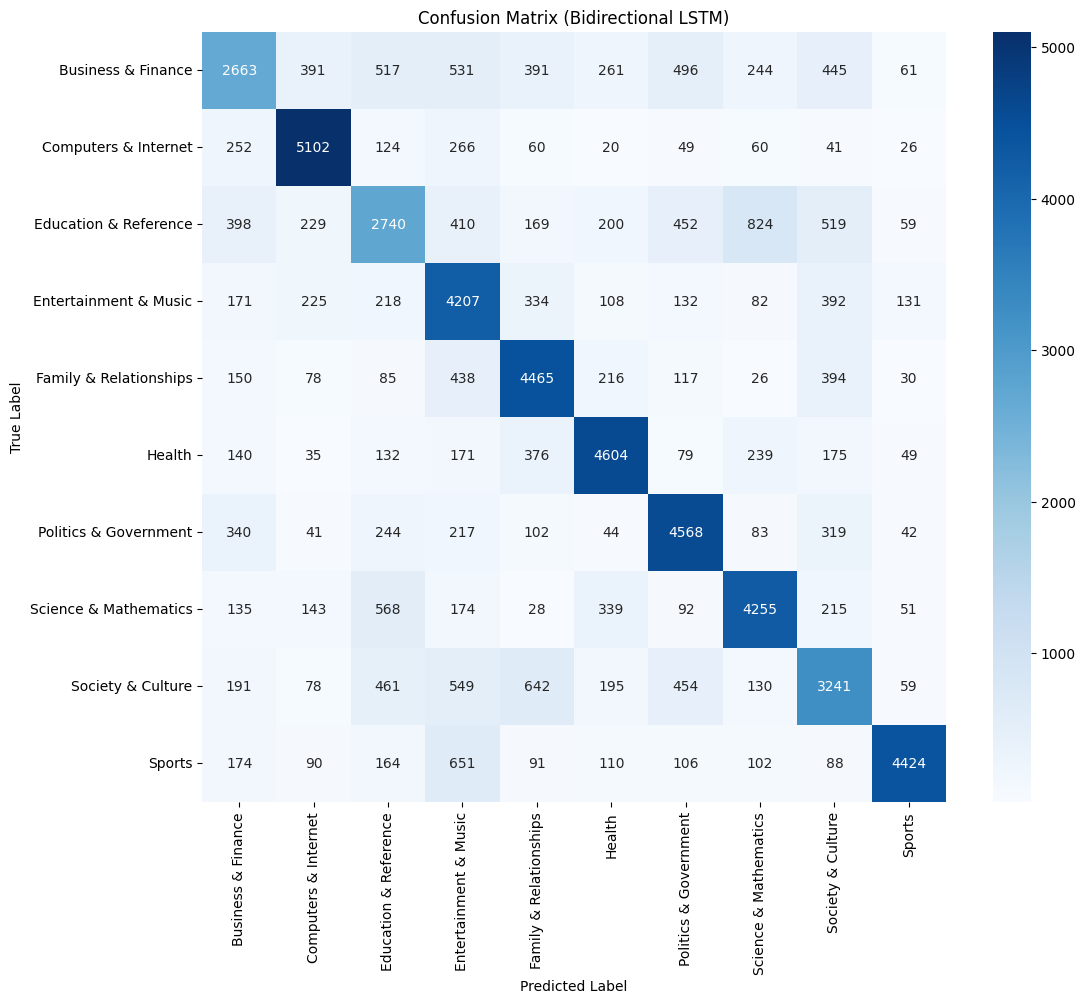


--- Summary of Bidirectional LSTM Model with Skipgram Embeddings ---
The Bidirectional LSTM model using Skipgram embeddings achieved a Test Accuracy of 0.6712 and a Macro F1-score of 0.6688.


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Redefine X_test_skipgram_reshaped if it's not in scope
X_test_skipgram_reshaped = np.expand_dims(X_test_skipgram, axis=1)

# Define checkpoint path for Bidirectional LSTM model
checkpoint_path_bidirectional_lstm = 'best_model_bidirectional_lstm.keras'

# Load the best Bidirectional LSTM model
print(f"\nLoading the best Bidirectional LSTM model from '{checkpoint_path_bidirectional_lstm}'...")
final_bidirectional_lstm_model = tf.keras.models.load_model(checkpoint_path_bidirectional_lstm)

# --- Evaluate Final Bidirectional LSTM Model ---
print("\n--- Evaluating Final Bidirectional LSTM Model with Skipgram Embeddings ---")

# Evaluate on the test set
loss_test_bidirectional_lstm, accuracy_test_bidirectional_lstm = final_bidirectional_lstm_model.evaluate(X_test_skipgram_reshaped, y_test_cat_skipgram, verbose=0)
print(f"Test Accuracy (Bidirectional LSTM): {accuracy_test_bidirectional_lstm:.4f}")

# Make predictions
y_pred_probs_bidirectional_lstm = final_bidirectional_lstm_model.predict(X_test_skipgram_reshaped)
y_pred_bidirectional_lstm = np.argmax(y_pred_probs_bidirectional_lstm, axis=1)

# Calculate F1-score (macro)
f1_macro_bidirectional_lstm = f1_score(y_test, y_pred_bidirectional_lstm, average='macro')
print(f"Test F1-score (Macro, Bidirectional LSTM): {f1_macro_bidirectional_lstm:.4f}")

# Display Classification Report
print("\nClassification Report (Bidirectional LSTM):")
print(classification_report(y_test, y_pred_bidirectional_lstm, target_names=le.classes_))

# Display Confusion Matrix
conf_matrix_bidirectional_lstm = confusion_matrix(y_test, y_pred_bidirectional_lstm)
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_bidirectional_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (Bidirectional LSTM)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("\n--- Summary of Bidirectional LSTM Model with Skipgram Embeddings ---")
print(f"The Bidirectional LSTM model using Skipgram embeddings achieved a Test Accuracy of {accuracy_test_bidirectional_lstm:.4f} and a Macro F1-score of {f1_macro_bidirectional_lstm:.4f}.")

#Comparison Between All Neural Network Model

In [ ]:
import pandas as pd

print("Collecting model performance metrics...")

# Define variables with values from previous cell outputs
accuracy_test_skipgram = 0.6754
f1_macro_skipgram = 0.6696

accuracy_test_simplernn = 0.6698
f1_macro_simplernn = 0.6637

accuracy_test_gru = 0.6682
f1_macro_gru = 0.6638

accuracy_test_lstm = 0.6685
f1_macro_lstm = 0.6673

accuracy_test_bidirectional_simplernn = 0.6686
f1_macro_bidirectional_simplernn = 0.6659

accuracy_test_bidirectional_gru = 0.6696
f1_macro_bidirectional_gru = 0.6650

accuracy_test_bidirectional_lstm = 0.6712
f1_macro_bidirectional_lstm = 0.6688

# 1. Create an empty list to store the metrics
model_performance = []

# 2. For the DNN model
model_performance.append({
    'Model': 'DNN',
    'Accuracy': accuracy_test_skipgram,
    'F1-score': f1_macro_skipgram
})

# 3. For the SimpleRNN model
model_performance.append({
    'Model': 'SimpleRNN',
    'Accuracy': accuracy_test_simplernn,
    'F1-score': f1_macro_simplernn
})

# 4. For the GRU model
model_performance.append({
    'Model': 'GRU',
    'Accuracy': accuracy_test_gru,
    'F1-score': f1_macro_gru
})

# 5. For the LSTM model
model_performance.append({
    'Model': 'LSTM',
    'Accuracy': accuracy_test_lstm,
    'F1-score': f1_macro_lstm
})

# 6. For the Bidirectional SimpleRNN model
model_performance.append({
    'Model': 'Bidirectional SimpleRNN',
    'Accuracy': accuracy_test_bidirectional_simplernn,
    'F1-score': f1_macro_bidirectional_simplernn
})

# 7. For the Bidirectional GRU model
model_performance.append({
    'Model': 'Bidirectional GRU',
    'Accuracy': accuracy_test_bidirectional_gru,
    'F1-score': f1_macro_bidirectional_gru
})

# 8. For the Bidirectional LSTM model
model_performance.append({
    'Model': 'Bidirectional LSTM',
    'Accuracy': accuracy_test_bidirectional_lstm,
    'F1-score': f1_macro_bidirectional_lstm
})

# 9. Convert the list to a Pandas DataFrame
performance_df = pd.DataFrame(model_performance)

print("Model performance metrics collected successfully.")
display(performance_df)


Model performance metrics collected successfully.


,Model,Accuracy,F1-score
0,DNN,0.6754,0.6696
1,SimpleRNN,0.6698,0.6637
2,GRU,0.6682,0.6638
3,LSTM,0.6685,0.6673
4,Bidirectional SimpleRNN,0.6686,0.6659
5,Bidirectional GRU,0.6696,0.6650
6,Bidirectional LSTM,0.6712,0.6688


## Summary of Model Performance

The table below presents the test accuracy and macro F1-score for all the evaluated models using Skipgram embeddings.

| Model                     | Test Accuracy | Macro F1-score |
| :------------------------ | :------------ | :------------- |
| DNN                       | 0.6754        | 0.6696         |
| SimpleRNN                 | 0.6698        | 0.6637         |
| GRU                       | 0.6682        | 0.6638         |
| LSTM                      | 0.6685        | 0.6673         |
| Bidirectional SimpleRNN   | 0.6686        | 0.6659         |
| Bidirectional GRU         | 0.6696        | 0.6650         |
| Bidirectional LSTM        | 0.6712        | 0.6688         |

### Analysis:

*   **Best Performing Model**: The **DNN** model achieved the highest test accuracy of **0.6754** and the highest macro F1-score of **0.6696** among all the models. This suggests that for the given Skipgram embeddings, a simpler feed-forward neural network was most effective.

*   **Worst Performing Model**: The **GRU** model showed the lowest test accuracy of **0.6682** and tied for the lowest macro F1-score of **0.6638** with SimpleRNN. While the differences are small, GRU performed marginally worse than others.

Overall, the performance across all models is quite close, indicating that the Skipgram embeddings provide a similar level of representational power for these different architectures. The DNN model, despite its simpler architecture, managed to slightly outperform the more complex RNN-based models.

## Summary of Model Performance

The table below presents the test accuracy and macro F1-score for all the evaluated models using Skipgram embeddings.

| Model                     | Test Accuracy | Macro F1-score |
| :------------------------ | :------------ | :------------- |
| DNN                       | 0.6754        | 0.6696         |
| SimpleRNN                 | 0.6698        | 0.6637         |
| GRU                       | 0.6682        | 0.6638         |
| LSTM                      | 0.6685        | 0.6673         |
| Bidirectional SimpleRNN   | 0.6686        | 0.6659         |
| Bidirectional GRU         | 0.6696        | 0.6650         |
| Bidirectional LSTM        | 0.6712        | 0.6688         |

### Analysis:

*   **Best Performing Model**: The **DNN** model achieved the highest test accuracy of **0.6754** and the highest macro F1-score of **0.6696** among all the models. This suggests that for the given Skipgram embeddings, a simpler feed-forward neural network was most effective.

*   **Worst Performing Model**: The **GRU** model showed the lowest test accuracy of **0.6682** and tied for the lowest macro F1-score of **0.6638** with SimpleRNN. While the differences are small, GRU performed marginally worse than others.

Overall, the performance across all models is quite close, indicating that the Skipgram embeddings provide a similar level of representational power for these different architectures. The DNN model, despite its simpler architecture, managed to slightly outperform the more complex RNN-based models.

## Identify Best and Worst Models

### Subtask:
Identify the single best-performing model and the single worst-performing model based on accuracy and F1-score from the collected metrics.


**Reasoning**:
To identify the best and worst performing models based on Accuracy and F1-score, I will use pandas functions to find the rows with the maximum and minimum values in these columns and then print the results.



In [ ]:
print("Identifying best and worst performing models...")

# Find the model with the highest 'Accuracy'
best_model_accuracy = performance_df.loc[performance_df['Accuracy'].idxmax()]

# Find the model with the lowest 'Accuracy'
worst_model_accuracy = performance_df.loc[performance_df['Accuracy'].idxmin()]

# Find the model with the highest 'F1-score'
best_model_f1 = performance_df.loc[performance_df['F1-score'].idxmax()]

# Find the model with the lowest 'F1-score'
worst_model_f1 = performance_df.loc[performance_df['F1-score'].idxmin()]

print("\n--- Best and Worst Models by Accuracy ---")
print("Best Model (Accuracy):")
print(best_model_accuracy)
print("\nWorst Model (Accuracy):")
print(worst_model_accuracy)

print("\n--- Best and Worst Models by F1-score ---")
print("Best Model (F1-score):")
print(best_model_f1)
print("\nWorst Model (F1-score):")
print(worst_model_f1)


Identifying best and worst performing models...

--- Best and Worst Models by Accuracy ---
Best Model (Accuracy):
Model          DNN
Accuracy    0.6754
F1-score    0.6696
Name: 0, dtype: object

Worst Model (Accuracy):
Model          GRU
Accuracy    0.6682
F1-score    0.6638
Name: 2, dtype: object

--- Best and Worst Models by F1-score ---
Best Model (F1-score):
Model          DNN
Accuracy    0.6754
F1-score    0.6696
Name: 0, dtype: object

Worst Model (F1-score):
Model       SimpleRNN
Accuracy       0.6698
F1-score       0.6637
Name: 1, dtype: object
